# 강서구 물류 최적화 시뮬레이션

## 프로젝트 개요
이 노트북은 강서구의 배송 데이터를 활용하여 최적의 물류 거점과 차량 운영 방안을 도출합니다.

### 주요 단계
1. 데이터 로드 (강서구 상가 배송지 + 강서구 배송출발지)
2. 도로망 데이터 로드 및 거점 매핑
3. VRP(차량 경로 문제) 시뮬레이션 (용량 제약 포함)
4. 결과 분석 및 시각화

---

## 2. 데이터 로드 (강서구 상가 배송지 + 배송출발지)

강서구의 상가 배송지 데이터(26,125개)와 5개 고정 배송출발지 데이터를 로드합니다.

In [29]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import sys
from IPython.display import clear_output

# 도로망 분석
import osmnx as ox
import networkx as nx
from scipy.spatial import cKDTree

# 최적화
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print("✓ 모든 라이브러리 로드 완료")

✓ 모든 라이브러리 로드 완료


## 2. 데이터 로드 (배송지 + 고정 거점)

강서구의 배송지 데이터와 5개 고정 거점 데이터를 로드합니다.

In [30]:
# 파일 경로 설정
delivery_file = '강서구_상가_위도경도도로명주소.xlsx'
depot_file = '강서구_배송출발지_좌표.csv'

# CSV 파일 안전 로드 함수
def read_csv_safe(p):
    for enc in ["utf-8-sig", "euc-kr", "cp949"]:
        try:
            df = pd.read_csv(p, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except UnicodeDecodeError:
            continue
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    return df

# 강서구 상가 배송지 데이터 로드 (Excel 파일)
df_deliveries = pd.read_excel(delivery_file)
df_deliveries.columns = df_deliveries.columns.str.strip()

# 데이터 확인
print(f"총 배송지 수: {len(df_deliveries):,}개")
print(f"\n컬럼 목록: {df_deliveries.columns.tolist()}")
print(f"\n데이터 샘플:")
df_deliveries.head()

c:\anaconda3\envs\my_env\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


총 배송지 수: 26,125개

컬럼 목록: ['상호명', '시도명', '시군구명', '도로명주소', 'Unnamed: 4', '경도', '위도']

데이터 샘플:


,상호명,시도명,시군구명,도로명주소,Unnamed: 4,경도,위도
0,김밥천국,서울특별시,강서구,서울특별시 강서구 까치산로 157,NaN,126.852441,37.551525
1,쭈꾸미마을,서울특별시,강서구,서울특별시 강서구 금낭화로15길 12,NaN,126.811112,37.574108
2,강서척정형외과,서울특별시,강서구,서울특별시 강서구 화곡로 301,NaN,126.848786,37.551286
3,가양성모내과의원,서울특별시,강서구,서울특별시 강서구 화곡로68길 3,NaN,126.854734,37.559583
4,감자와눈사람여성의원,서울특별시,강서구,서울특별시 강서구 마곡중앙5로 22,NaN,126.825301,37.567246


In [31]:
# 배송지 데이터 검증 및 변환
if '위도' not in df_deliveries.columns or '경도' not in df_deliveries.columns:
    raise KeyError("필수 칼럼(위도, 경도)이 배송지 데이터에 없습니다.")

df_deliveries['위도'] = pd.to_numeric(df_deliveries['위도'], errors='coerce')
df_deliveries['경도'] = pd.to_numeric(df_deliveries['경도'], errors='coerce')

# 유효한 좌표만 사용
df_valid_coords = df_deliveries.dropna(subset=['위도', '경도'])

print(f"\n배송지 데이터:")
print(f"  - 총 배송지: {len(df_deliveries):,}개")
print(f"  - 유효 좌표: {len(df_valid_coords):,}개")
print(f"  - 무효 좌표: {len(df_deliveries) - len(df_valid_coords):,}개")

# 강서구 배송출발지 데이터 로드
df_depots = read_csv_safe(depot_file)

# 거점 데이터 검증
if '위도' not in df_depots.columns or '경도' not in df_depots.columns:
    raise KeyError(f"{depot_file}에 필수 칼럼(위도, 경도)이 없습니다.")

df_depots['위도'] = pd.to_numeric(df_depots['위도'], errors='coerce')
df_depots['경도'] = pd.to_numeric(df_depots['경도'], errors='coerce')
df_depots = df_depots.dropna(subset=['위도', '경도'])  # 유효한 거점만 사용

print(f"\n배송출발지 데이터:")
print(f"  - 총 거점: {len(df_depots)}개")
for idx, row in df_depots.iterrows():
    print(f"  {idx+1}. {row['사업장명']}")
    print(f"     위치: 위도 {row['위도']:.6f}, 경도 {row['경도']:.6f}")


배송지 데이터:
  - 총 배송지: 26,125개
  - 유효 좌표: 26,125개
  - 무효 좌표: 0개

배송출발지 데이터:
  - 총 거점: 5개
  1. 쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동))
     위치: 위도 37.572847, 경도 126.837599
  2. 쿠팡로지스틱스서비스 유한회사 (강서1캠프)
     위치: 위도 37.558998, 경도 126.859658
  3. (주)와우로지스틱스
     위치: 위도 37.555891, 경도 126.808109
  4. (주)한진 강서택배센터
     위치: 위도 37.548269, 경도 126.815920
  5. (주)케이더블유이코리아
     위치: 위도 37.567813, 경도 126.815994


## 3. 도로망 데이터 로드 및 거점 매핑

**중요**: 배송출발지와 배송지가 모두 강서구에 위치하므로 **강서구 도로망**을 로드합니다.

- **배송출발지 위치**: 강서구 (5개 물류센터)
- **배송지 위치**: 강서구 (26,125개 상가)
- **도로망 범위**: 강서구

⏱️ **첫 실행 시 주의**: 강서구 도로망 다운로드는 1-2분 정도 소요됩니다.

In [32]:
# 도로망 데이터 로드 (강서구)
place_name = 'Gangseo-gu, Seoul, South Korea'
graph_path = 'gangseo_drive_network.graphml'

try:
    G = ox.load_graphml(graph_path)
    print(f"✓ '{graph_path}' 파일에서 도로망 데이터를 불러왔습니다.")
except FileNotFoundError:
    print(f"'{graph_path}' 파일이 없어 새로 다운로드합니다...")
    print("⚠️ 강서구 도로망 다운로드 중입니다 (1-2분 소요)...")
    G = ox.graph_from_place(place_name, network_type='drive')
    ox.save_graphml(G, graph_path)
    print(f"✓ 도로망 데이터를 '{graph_path}'에 저장했습니다.")

print(f"\n도로망 정보:")
print(f"  - 노드(교차로) 수: {len(G.nodes):,}개")
print(f"  - 엣지(도로) 수: {len(G.edges):,}개")
print(f"  - 범위: 강서구 (배송출발지 + 배송지 모두 포함)")

✓ 'gangseo_drive_network.graphml' 파일에서 도로망 데이터를 불러왔습니다.

도로망 정보:
  - 노드(교차로) 수: 2,626개
  - 엣지(도로) 수: 7,535개
  - 범위: 강서구 (배송출발지 + 배송지 모두 포함)


In [33]:
# 5개 거점을 도로망의 가장 가까운 노드로 매핑
depot_nodes = ox.distance.nearest_nodes(G, X=df_depots['경도'], Y=df_depots['위도'])
depot_nodes_list = depot_nodes.tolist() if hasattr(depot_nodes, 'tolist') else list(depot_nodes)

print(f"\n거점 매핑 결과 (도로망 노드):")
for i, (depot_id, row) in enumerate(zip(depot_nodes_list, df_depots.itertuples())):
    node_info = G.nodes[depot_id]
    print(f"{i+1}. {row.사업장명}")
    print(f"   노드 ID: {depot_id}")
    print(f"   원본 좌표: ({row.위도:.6f}, {row.경도:.6f})")
    print(f"   매핑된 좌표: ({node_info['y']:.6f}, {node_info['x']:.6f})\n")


거점 매핑 결과 (도로망 노드):
1. 쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동))
   노드 ID: 2825950827
   원본 좌표: (37.572847, 126.837599)
   매핑된 좌표: (37.572486, 126.837226)

2. 쿠팡로지스틱스서비스 유한회사 (강서1캠프)
   노드 ID: 10814323683
   원본 좌표: (37.558998, 126.859658)
   매핑된 좌표: (37.558583, 126.859749)

3. (주)와우로지스틱스
   노드 ID: 4602990169
   원본 좌표: (37.555891, 126.808109)
   매핑된 좌표: (37.557182, 126.809722)

4. (주)한진 강서택배센터
   노드 ID: 12400403830
   원본 좌표: (37.548269, 126.815920)
   매핑된 좌표: (37.548224, 126.816584)

5. (주)케이더블유이코리아
   노드 ID: 12979259896
   원본 좌표: (37.567813, 126.815994)
   매핑된 좌표: (37.568151, 126.816255)



### 도로망 시각화 (선택 사항)

강서구 도로망의 구조를 확인해봅니다. 전체 네트워크가 복잡하므로 일부 영역만 표시합니다.

✓ 도로망 시각화 저장 완료: 강서구_도로망_구조.png


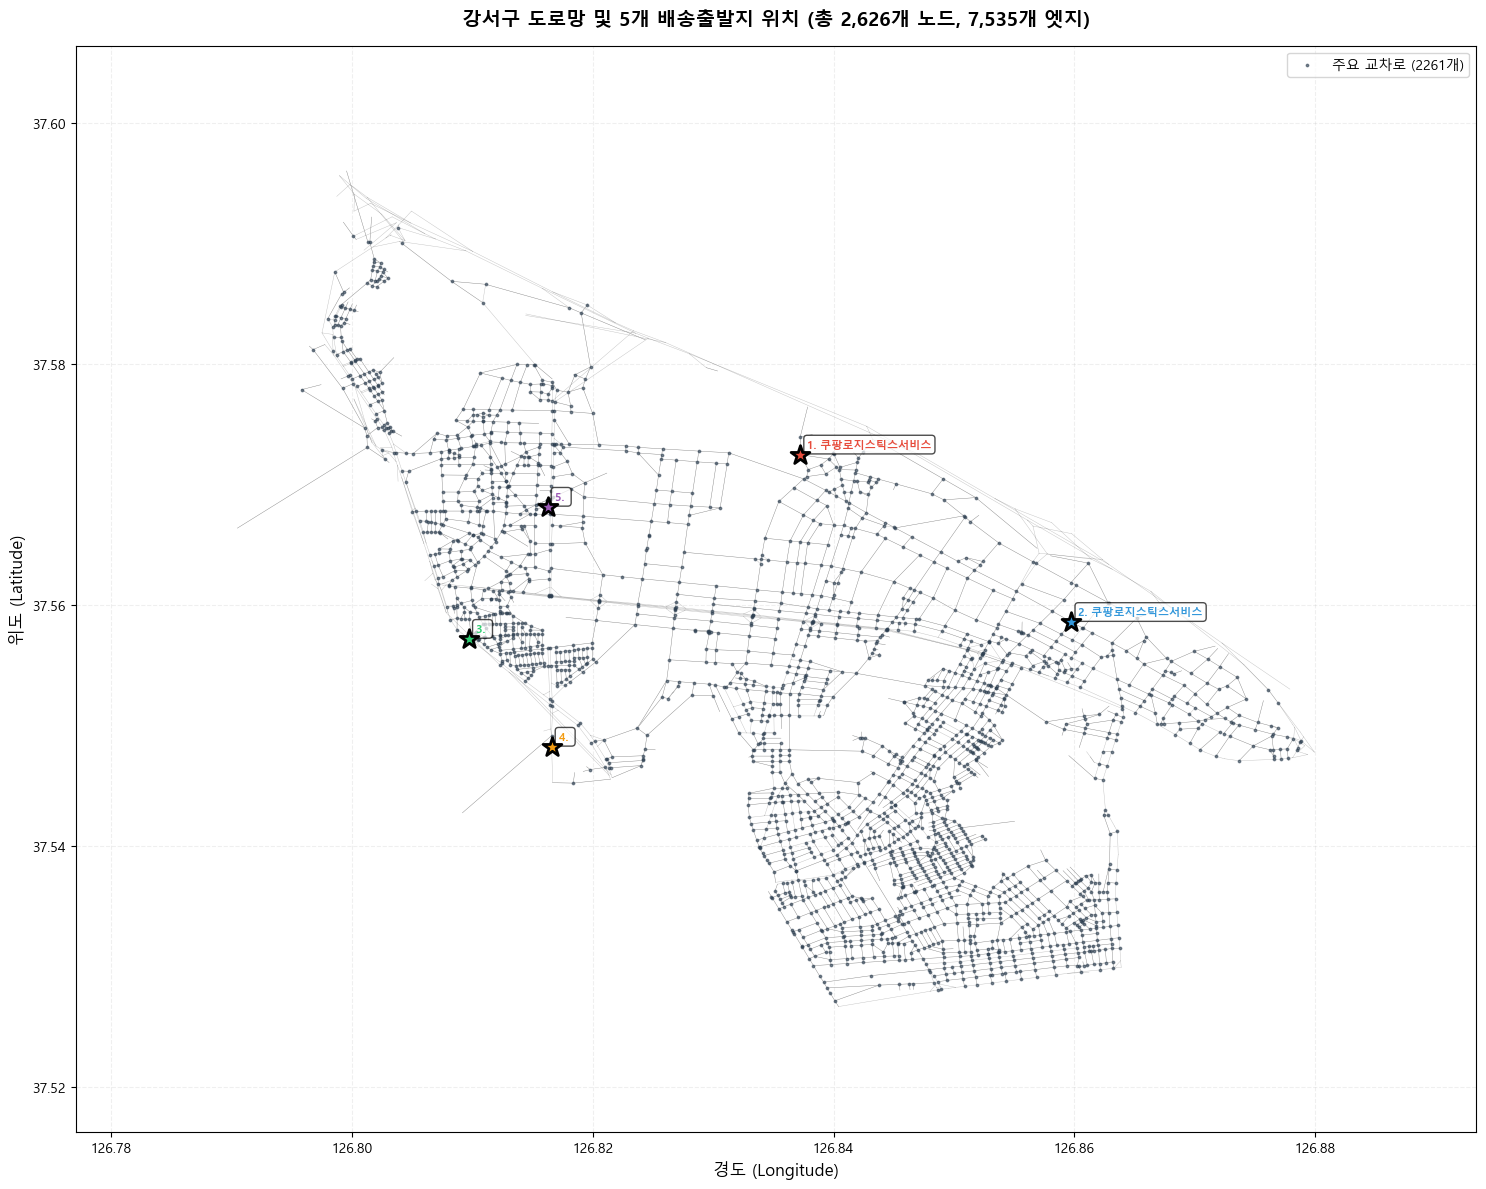


도로망 통계:
  - 전체 노드(교차로): 2,626개
  - 전체 엣지(도로): 7,535개
  - 주요 교차로 (degree≥4): 2,261개
  - 평균 연결도: 5.74


In [34]:
# 도로망 시각화 (전체 또는 일부)
fig, ax = plt.subplots(figsize=(16, 12))

# 방법 2: NetworkX로 직접 그리기 (빠르고 커스터마이즈 가능)
# 노드 위치 추출
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# 모든 엣지 그리기 (도로)
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

ax.plot(edge_x, edge_y, 'gray', linewidth=0.3, alpha=0.5, zorder=1)

# 주요 교차로만 표시 (degree가 높은 노드)
node_degrees = dict(G.degree())
major_nodes = [node for node, degree in node_degrees.items() if degree >= 4]
major_x = [pos[node][0] for node in major_nodes]
major_y = [pos[node][1] for node in major_nodes]
ax.scatter(major_x, major_y, c='#2c3e50', s=3, alpha=0.6, zorder=2, label=f'주요 교차로 ({len(major_nodes)}개)')

# 5개 고정 거점 강조 표시
depot_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i, depot_id in enumerate(depot_nodes_list):
    depot_x, depot_y = pos[depot_id]
    ax.scatter(depot_x, depot_y, c=depot_colors[i], s=200, marker='*', 
              edgecolors='black', linewidth=2, zorder=5)
    depot_name = df_depots.iloc[i]['사업장명'].split('(')[0][:10]  # 이름 축약
    ax.annotate(f'{i+1}. {depot_name}', (depot_x, depot_y), 
               xytext=(5, 5), textcoords='offset points', 
               fontsize=8, fontweight='bold', color=depot_colors[i],
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# 그래프 설정
ax.set_xlabel('경도 (Longitude)', fontsize=12)
ax.set_ylabel('위도 (Latitude)', fontsize=12)
ax.set_title(f'강서구 도로망 및 5개 배송출발지 위치 (총 {len(G.nodes):,}개 노드, {len(G.edges):,}개 엣지)', 
            fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

# 거점이 보이도록 축 범위 확장
all_lats = [pos[node][1] for node in G.nodes()] + [G.nodes[d]['y'] for d in depot_nodes_list]
all_lons = [pos[node][0] for node in G.nodes()] + [G.nodes[d]['x'] for d in depot_nodes_list]
lat_margin = (max(all_lats) - min(all_lats)) * 0.15
lon_margin = (max(all_lons) - min(all_lons)) * 0.15
ax.set_xlim(min(all_lons) - lon_margin, max(all_lons) + lon_margin)
ax.set_ylim(min(all_lats) - lat_margin, max(all_lats) + lat_margin)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('강서구_도로망_구조.png', dpi=200, bbox_inches='tight')
print("✓ 도로망 시각화 저장 완료: 강서구_도로망_구조.png")
plt.show()

print(f"\n도로망 통계:")
print(f"  - 전체 노드(교차로): {len(G.nodes):,}개")
print(f"  - 전체 엣지(도로): {len(G.edges):,}개")
print(f"  - 주요 교차로 (degree≥4): {len(major_nodes):,}개")
print(f"  - 평균 연결도: {sum(node_degrees.values())/len(node_degrees):.2f}")

## 4. 시뮬레이션 파라미터 설정 및 배송지 샘플링

In [35]:
# 차량 정보 설정
vehicles = {
    'diesel_1t': {
        'name': '1톤 디젤 트럭',
        'fuel_efficiency': 8.5,  # km/L
        'co2_per_liter': 2.64,   # kg/L
        'cost_per_km': 250,      # 원/km (유류비)
        'capacity': 20,          # 최대 적재 용량 (박스) - 거점당 1-3대 운영 목표
    }
}

# 비용 파라미터
current_carbon_tax_per_kg_co2 = 20  # 탄소세 (원/kgCO2)
driver_wage_per_hour = 18000  # 시간당 인건비
avg_speed_kph = 35  # 평균 주행 속도
driver_wage_per_km = driver_wage_per_hour / avg_speed_kph  # km당 인건비

print("차량 정보:")
for key, vehicle in vehicles.items():
    print(f"\n  {vehicle['name']}")
    print(f"    - 연비: {vehicle['fuel_efficiency']} km/L")
    print(f"    - CO2 배출: {vehicle['co2_per_liter']} kg/L")
    print(f"    - 운행 비용: {vehicle['cost_per_km']}원/km (유류)")
    print(f"    - 인건비: {driver_wage_per_km:.0f}원/km")
    print(f"    - 총 운행 비용: {vehicle['cost_per_km'] + driver_wage_per_km:.0f}원/km")
    print(f"    - 적재 용량: {vehicle['capacity']}박스")

print(f"\n탄소세: {current_carbon_tax_per_kg_co2}원/kgCO2")

차량 정보:

  1톤 디젤 트럭
    - 연비: 8.5 km/L
    - CO2 배출: 2.64 kg/L
    - 운행 비용: 250원/km (유류)
    - 인건비: 514원/km
    - 총 운행 비용: 764원/km
    - 적재 용량: 20박스

탄소세: 20원/kgCO2


In [36]:
# 배송지 샘플링 및 수요량 설정
# 강서구 상가가 26,125개로 많으므로 샘플링 진행
# 빠른 실행을 위해 샘플 수 축소 (100개 → 45개)
num_samples = 45
df_sample = df_valid_coords.sample(n=num_samples)  # random_state 제거 → 매번 다른 배송지

# 실제와 유사한 수요량 분포 설정 (단위: 박스)
# 상가 규모별 수요량을 현실적으로 랜덤 부여 (시드 제거 → 매번 다른 수요량)

# 상가 수요량 분포 (실제 상가 특성 반영)
# - 소형 상점 (40%): 1-4박스
# - 중형 상점 (40%): 5-10박스  
# - 대형 상점 (20%): 11-20박스
demand_distribution = []
for i in range(num_samples):
    rand = np.random.random()
    if rand < 0.4:  # 소형 상점 40%
        demand = np.random.randint(1, 5)  # 1-4박스
    elif rand < 0.8:  # 중형 상점 40%
        demand = np.random.randint(5, 11)  # 5-10박스
    else:  # 대형 상점 20%
        demand = np.random.randint(11, 21)  # 11-20박스
    demand_distribution.append(demand)

df_sample['수요량'] = demand_distribution

# 배송지를 도로망 노드로 매핑
delivery_nodes = ox.distance.nearest_nodes(G, X=df_sample['경도'], Y=df_sample['위도'])
demands = df_sample['수요량'].tolist()

print(f"\n샘플링 정보 (현실적 수요량 분포):")
print(f"  - 총 배송지: {len(df_valid_coords):,}개 (강서구 상가)")
print(f"  - 샘플 배송지: {num_samples}개 (테스트용 축소)")
print(f"  - 총 수요량: {sum(demands):.0f}박스")
print(f"  - 평균 수요량: {sum(demands)/len(demands):.1f}박스/지점")
print(f"  - 최소 수요량: {min(demands)}박스")
print(f"  - 최대 수요량: {max(demands)}박스")
print(f"  - 표준편차: {np.std(demands):.1f}박스")
print(f"  - 최소 필요 차량(용량 20박스): {np.ceil(sum(demands)/20):.0f}대")
print(f"  - 거점당 예상 차량: {np.ceil(sum(demands)/20/5):.1f}대")

print(f"\n배송지 특성 (현실 반영):")
print(f"  - 소형 상점 (40%): 1-4박스 - 편의점, 소규모 매장")
print(f"  - 중형 상점 (40%): 5-10박스 - 식당, 중형 소매점")
print(f"  - 대형 상점 (20%): 11-20박스 - 마트, 대형 음식점")

print(f"\n수요량 분포:")
small = sum(1 for d in demands if d <= 4)
medium = sum(1 for d in demands if 5 <= d <= 10)
large = sum(1 for d in demands if d >= 11)
print(f"  - 소형: {small}개 ({small/len(demands)*100:.1f}%)")
print(f"  - 중형: {medium}개 ({medium/len(demands)*100:.1f}%)")
print(f"  - 대형: {large}개 ({large/len(demands)*100:.1f}%)")

print(f"\n차량 운영 계획:")
theoretical_min = int(np.ceil(sum(demands)/20))
print(f"  - 이론적 최소 차량: {theoretical_min}대")
print(f"  - 목표: 5개 거점에 균형있게 {theoretical_min}~{theoretical_min+5}대 배치")
print(f"  - 거점당 목표: 1~5대 (최소 비용 최적화)")

print(f"\n💡 실제 운영 시에는 num_samples=100으로 조정하세요.")


샘플링 정보 (현실적 수요량 분포):
  - 총 배송지: 26,125개 (강서구 상가)
  - 샘플 배송지: 45개 (테스트용 축소)
  - 총 수요량: 307박스
  - 평균 수요량: 6.8박스/지점
  - 최소 수요량: 1박스
  - 최대 수요량: 19박스
  - 표준편차: 4.6박스
  - 최소 필요 차량(용량 20박스): 16대
  - 거점당 예상 차량: 4.0대

배송지 특성 (현실 반영):
  - 소형 상점 (40%): 1-4박스 - 편의점, 소규모 매장
  - 중형 상점 (40%): 5-10박스 - 식당, 중형 소매점
  - 대형 상점 (20%): 11-20박스 - 마트, 대형 음식점

수요량 분포:
  - 소형: 17개 (37.8%)
  - 중형: 21개 (46.7%)
  - 대형: 7개 (15.6%)

차량 운영 계획:
  - 이론적 최소 차량: 16대
  - 목표: 5개 거점에 균형있게 16~21대 배치
  - 거점당 목표: 1~5대 (최소 비용 최적화)

💡 실제 운영 시에는 num_samples=100으로 조정하세요.


## 5. VRP 해결 함수 정의

용량 제약이 있는 차량 경로 문제(CVRP)를 해결하는 함수들을 정의합니다.

In [37]:
# 거리 계산 메모이제이션
memo_distances = {}

def get_distance_km(from_node, to_node):
    """두 노드 간의 최단 거리(km) 계산"""
    if (from_node, to_node) in memo_distances:
        return memo_distances[(from_node, to_node)]
    try:
        distance_m = nx.shortest_path_length(G, source=from_node, target=to_node, weight='length')
        distance_km = distance_m / 1000
        memo_distances[(from_node, to_node)] = distance_km
        return distance_km
    except nx.NetworkXNoPath:
        return np.inf  # 경로가 없으면 무한대 비용

def create_cost_matrix(vrp_nodes, vehicle_type, tax_rate_per_kg):
    """
    노드 간 이동 비용 매트릭스 생성
    
    비용 구성: 운행비용(유류+인건비) + 탄소세
    
    Args:
        vrp_nodes: 노드 ID 리스트 (거점 + 배송지)
        vehicle_type: 차량 종류 ('diesel_1t')
        tax_rate_per_kg: kg당 탄소세 (원/kgCO2)
    
    Returns:
        numpy.ndarray: N×N 비용 매트릭스 (int32)
    """
    num_nodes = len(vrp_nodes)
    cost_matrix = np.zeros((num_nodes, num_nodes), dtype=np.int32)
    vehicle = vehicles[vehicle_type]
    
    # CO2 배출량 계산
    if 'co2_per_liter' in vehicle:
        co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    else:
        kwh_per_km = 1 / vehicle['energy_efficiency']
        co2_per_km = vehicle['co2_per_kwh'] * kwh_per_km
    
    # 비용 매트릭스 계산
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j: 
                continue
            distance_km = get_distance_km(vrp_nodes[i], vrp_nodes[j])
            if distance_km == np.inf:
                cost_matrix[i][j] = 99999  # 오버플로우 방지
                continue
            
            operational_cost = (vehicle['cost_per_km'] + driver_wage_per_km) * distance_km
            carbon_cost = (co2_per_km * tax_rate_per_kg) * distance_km
            total_cost = operational_cost + carbon_cost
            
            # 직접 정수로 변환 (스케일링 불필요 - 강서구 내부 배송)
            cost_matrix[i][j] = int(total_cost)
            if cost_matrix[i][j] == 0:  # 0이 되지 않도록 최소값 보장
                cost_matrix[i][j] = 1
    
    return cost_matrix

print("✓ VRP 함수 정의 완료")

✓ VRP 함수 정의 완료


In [38]:
def solve_vrp(cost_matrix, num_vehicles, demands, vehicle_capacity, return_routes=False):
    """
    [참고용 함수 - 단일 거점 VRP]
    용량 제약이 있는 VRP 문제를 해결합니다 (Capacitated VRP).
    
    NOTE: 현재 MDVRP에서는 solve_mdvrp()를 사용합니다.
          이 함수는 단일 거점 시나리오나 테스트용으로 보관됩니다.
    
    Args:
        cost_matrix: 노드 간 이동 비용 매트릭스
        num_vehicles: 사용할 차량 대수
        demands: 각 노드(배송지)의 수요량 리스트 (인덱스 0은 거점이므로 0)
        vehicle_capacity: 각 차량의 최대 적재 용량
        return_routes: True이면 (비용, 경로정보) 반환, False이면 비용만 반환
    
    Returns:
        return_routes=False: 총 물류비용 (원)
        return_routes=True: (총 물류비용, 차량별 경로 리스트)
    """
    manager = pywrapcp.RoutingIndexManager(len(cost_matrix), num_vehicles, 0)
    routing = pywrapcp.RoutingModel(manager)
    
    # 1. 비용(거리) 콜백 함수 등록
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return cost_matrix[from_node][to_node]
    
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    # 2. 수요량(용량) 콜백 함수 등록
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return demands[from_node]
    
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    
    # 3. 용량 제약 추가
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack (용량 여유 없음)
        [vehicle_capacity] * num_vehicles,  # 각 차량의 용량
        True,  # start cumul to zero (시작 시 적재량 0)
        'Capacity'
    )
    
    # 4. 탐색 파라미터 설정
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 60  # 최대 60초 탐색 (개선: 30→60)
    search_parameters.log_search = False  # OR-Tools 로그 출력 비활성화
    
    # 5. 문제 해결
    solution = routing.SolveWithParameters(search_parameters)
    if solution:
        # 최적화된 총 비용 (스케일링 없음)
        total_cost = solution.ObjectiveValue()
        
        # 경로 정보 추출 (요청 시)
        if return_routes:
            routes = []
            for vehicle_id in range(num_vehicles):
                route = []
                index = routing.Start(vehicle_id)
                while not routing.IsEnd(index):
                    node_index = manager.IndexToNode(index)
                    route.append(node_index)
                    index = solution.Value(routing.NextVar(index))
                # 마지막 거점 추가
                route.append(manager.IndexToNode(index))
                # 거점만 방문한 빈 경로 제외 (거점 → 거점)
                if len(route) > 2:
                    routes.append(route)
            return total_cost, routes
        else:
            return total_cost
    
    if return_routes:
        return None, []
    return None

print("✓ VRP 솔버 함수 정의 완료")

✓ VRP 솔버 함수 정의 완료


## 5-2. MDVRP (Multi-Depot VRP) 함수 정의

고객을 거점에 할당하고, 각 거점별로 CVRP를 해결하는 MDVRP 시스템을 구축합니다.

In [39]:
def assign_customers_to_depots(depot_nodes_list, delivery_nodes_list, delivery_coords):
    """
    [참고용 함수 - 현재 미사용]
    각 고객을 가장 가까운 거점에 할당합니다 (최소 비용 - 유클리드 거리 기반).
    
    NOTE: 현재 solve_mdvrp에서 OR-Tools의 통합 최적화를 사용하므로 이 함수는 호출되지 않습니다.
          고객 할당과 경로 최적화가 동시에 진행됩니다.
    
    Args:
        depot_nodes_list: 거점 노드 ID 리스트
        delivery_nodes_list: 배송지 노드 ID 리스트
        delivery_coords: 배송지 좌표 [(lat, lon), ...] 리스트
    
    Returns:
        dict: {depot_node_id: [customer_indices]}
    """
    from scipy.spatial.distance import cdist
    
    assignments = {depot: [] for depot in depot_nodes_list}
    
    # 빈 배송지 처리
    if len(delivery_coords) == 0 or len(delivery_nodes_list) == 0:
        print("  ⚠️ 배송지가 없습니다.")
        return assignments
    
    # 거점 좌표 가져오기
    depot_coords = []
    for depot_node in depot_nodes_list:
        node_info = G.nodes[depot_node]
        depot_coords.append([node_info['y'], node_info['x']])  # lat, lon
    
    depot_coords = np.array(depot_coords)
    customer_coords = np.array(delivery_coords)
    
    print(f"  거점 좌표: {len(depot_coords)}개")
    print(f"  고객 좌표: {len(customer_coords)}개")
    print(f"  📍 최소 비용 할당: 각 고객을 가장 가까운 거점에 배정")
    
    # 유클리드 거리 기반으로 가장 가까운 거점에 할당
    distances = cdist(customer_coords, depot_coords, metric='euclidean')
    
    for cust_idx in range(len(delivery_nodes_list)):
        nearest_depot_idx = np.argmin(distances[cust_idx])
        assigned_depot = depot_nodes_list[nearest_depot_idx]
        assignments[assigned_depot].append(cust_idx)
        
        # 디버깅 정보 (처음 5개만)
        if cust_idx < 5:
            print(f"  고객 {cust_idx}: ({customer_coords[cust_idx][0]:.4f}, {customer_coords[cust_idx][1]:.4f}) "
                  f"→ 거점 {nearest_depot_idx+1} (거리: {distances[cust_idx][nearest_depot_idx]:.6f})")
    
    # 할당 통계
    print(f"\n  할당 결과:")
    active_depots = 0
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        count = len(assignments[depot_node])
        if count > 0:
            active_depots += 1
        status = "✓" if count > 0 else "○"
        print(f"    거점 {depot_idx+1}: {count}명 할당 {status}")
    
    print(f"\n  ✓ 활성 거점: {active_depots}개 / {len(depot_nodes_list)}개 (최소 비용 최적화)")
    
    return assignments

def calculate_min_vehicles(total_demand, vehicle_capacity):
    """
    [유틸리티 함수]
    수요량과 용량을 기반으로 필요한 최소 차량 대수를 계산합니다.
    
    Args:
        total_demand: 총 수요량 (박스)
        vehicle_capacity: 차량 용량 (박스)
    
    Returns:
        int: 이론적 최소 필요 차량 대수
    
    Example:
        >>> calculate_min_vehicles(350, 20)  # 350박스 / 20박스 = 18대
        18
    """
    if vehicle_capacity <= 0:
        return 0
    return int(np.ceil(total_demand / vehicle_capacity))

print("✓ MDVRP 보조 함수 정의 완료")


✓ MDVRP 보조 함수 정의 완료


In [40]:
def solve_mdvrp(depot_nodes_list, depot_names, delivery_nodes_list, delivery_coords, 
                demands_list, vehicle_type='diesel_1t', tax_rate_per_kg=50):
    """
    통합 Multi-Depot VRP 최적화 솔버 (OR-Tools 기반)
    
    🎯 핵심 개념:
    - 고객 할당과 차량 경로를 동시에 최적화 (2단계 → 1단계 통합)
    - 각 거점에서 독립적으로 차량 출발/복귀
    - 총 물류비용 최소화를 목적함수로 설정
    
    📊 최적화 과정:
    1. 통합 비용 매트릭스 생성 (모든 거점 + 모든 배송지)
    2. OR-Tools Multi-Depot VRP 모델 구성
    3. 동시 최적화 실행 (고객 할당 + 경로 계획)
    4. 거점별 결과 분석 및 반환
    
    Args:
        depot_nodes_list: 거점 노드 ID 리스트
        depot_names: 거점 이름 리스트
        delivery_nodes_list: 배송지 노드 ID 리스트  
        delivery_coords: 배송지 좌표 리스트 [(lat, lon), ...]
        demands_list: 배송지별 수요량 리스트
        vehicle_type: 차량 종류
        tax_rate_per_kg: 탄소세율
    
    Returns:
        tuple: (거점별 결과 dict, 총 비용, 총 차량 수)
    """
    vehicle = vehicles[vehicle_type]
    vehicle_capacity = vehicle['capacity']
    num_depots = len(depot_nodes_list)
    num_customers = len(delivery_nodes_list)
    
    # 총 수요량 기반 이론적 최소 차량 계산
    total_demand = sum(demands_list)
    theoretical_min_vehicles = int(np.ceil(total_demand / vehicle_capacity))
    
    # 거점당 최대 차량: 이론적 최소의 150% / 거점 수 (여유 있게)
    max_vehicles_per_depot = max(5, int(np.ceil(theoretical_min_vehicles * 1.5 / num_depots)))
    total_vehicles = num_depots * max_vehicles_per_depot
    
    print("\n" + "="*80)
    print("통합 Multi-Depot VRP 최적화 시작 (최소 비용 목적함수)")
    print("="*80)
    print(f"거점 수: {num_depots}개")
    print(f"배송지 수: {num_customers}개")
    print(f"총 수요량: {total_demand:.0f}박스")
    print(f"차량 용량: {vehicle_capacity}박스")
    print(f"이론적 최소 차량: {theoretical_min_vehicles}대")
    print(f"거점당 최대 차량: {max_vehicles_per_depot}대 (동적 계산)")
    print(f"총 가용 차량: {total_vehicles}대")
    
    # 1단계: 비용 매트릭스 생성 (모든 거점 + 모든 배송지)
    print("\n1단계: 통합 비용 매트릭스 생성 중...")
    all_nodes = depot_nodes_list + delivery_nodes_list
    num_nodes = len(all_nodes)
    
    cost_matrix = np.zeros((num_nodes, num_nodes), dtype=np.int32)
    
    # CO2 배출량 계산
    co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                continue
            distance_km = get_distance_km(all_nodes[i], all_nodes[j])
            if distance_km == np.inf:
                cost_matrix[i][j] = 99999
                continue
            
            operational_cost = (vehicle['cost_per_km'] + driver_wage_per_km) * distance_km
            carbon_cost = (co2_per_km * tax_rate_per_kg) * distance_km
            total_cost_val = operational_cost + carbon_cost
            cost_matrix[i][j] = int(total_cost_val)
            if cost_matrix[i][j] == 0:
                cost_matrix[i][j] = 1
    
    print(f"  ✓ 비용 매트릭스 생성 완료: {cost_matrix.shape}")
    
    # 2단계: OR-Tools Multi-Depot VRP 모델 구성
    print("\n2단계: Multi-Depot VRP 모델 구성 중...")
    
    # 각 차량의 시작/종료 거점 설정
    starts = []
    ends = []
    for depot_idx in range(num_depots):
        for _ in range(max_vehicles_per_depot):
            starts.append(depot_idx)  # 거점 인덱스 (0~4)
            ends.append(depot_idx)
    
    manager = pywrapcp.RoutingIndexManager(num_nodes, total_vehicles, starts, ends)
    routing = pywrapcp.RoutingModel(manager)
    
    # 비용 콜백
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return cost_matrix[from_node][to_node]
    
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)
    
    # 수요량 콜백 (거점은 수요 0, 배송지는 실제 수요)
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        if from_node < num_depots:  # 거점
            return 0
        else:  # 배송지
            return demands_list[from_node - num_depots]
    
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    
    # 용량 제약
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        [vehicle_capacity] * total_vehicles,
        True,
        'Capacity'
    )
    
    # 탐색 파라미터 설정
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 180  # 배송지 증가로 시간 연장 (120→180초)
    search_parameters.log_search = False
    
    print("  ✓ 모델 구성 완료")
    
    # 3단계: 문제 해결
    print("\n3단계: 최적화 실행 중 (최대 180초)...")
    print("  목적: 총 물류비용 최소화 + 차량 수 자동 최적화")
    
    solution = routing.SolveWithParameters(search_parameters)
    
    if not solution:
        print("  ✗ 해를 찾지 못했습니다.")
        return {}, 0, 0
    
    # 4단계: 결과 추출 및 분석
    print("\n4단계: 결과 분석 중...")
    total_cost = solution.ObjectiveValue()  # 최적화된 총 비용
    
    # 거점별 결과 초기화
    results = {}
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        results[depot_node] = {
            'depot_name': depot_names[depot_idx],
            'depot_node': depot_node,
            'num_customers': 0,
            'customer_indices': [],
            'total_demand': 0,
            'num_vehicles': 0,
            'total_cost': 0,
            'routes': []
        }
    
    # 각 차량의 경로 추출
    used_vehicles = 0
    for vehicle_id in range(total_vehicles):
        route = []
        index = routing.Start(vehicle_id)
        
        # 경로 추출
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route.append(node_index)
            index = solution.Value(routing.NextVar(index))
        route.append(manager.IndexToNode(index))
        
        # 빈 경로 제외 (거점 → 거점만)
        if len(route) <= 2:
            continue
        
        used_vehicles += 1
        
        # 이 차량이 어느 거점에서 출발했는지 확인
        depot_idx = route[0]  # 시작 노드 = 거점 인덱스
        depot_node = depot_nodes_list[depot_idx]
        
        # 배송지만 추출 (거점 제외)
        customers_in_route = [node_idx - num_depots for node_idx in route[1:-1] if node_idx >= num_depots]
        route_demand = sum(demands_list[cust_idx] for cust_idx in customers_in_route)
        
        # 경로 비용 계산
        route_cost = 0
        for i in range(len(route) - 1):
            route_cost += cost_matrix[route[i]][route[i+1]]
        # route_cost는 이미 실제 비용 (스케일링 없음)
        
        # 거점 결과에 추가
        results[depot_node]['num_vehicles'] += 1
        results[depot_node]['num_customers'] += len(customers_in_route)
        results[depot_node]['customer_indices'].extend(customers_in_route)
        results[depot_node]['total_demand'] += route_demand
        results[depot_node]['total_cost'] += route_cost
        results[depot_node]['routes'].append(route)
    
    # 거점별 평균 비용 계산
    for depot_node in results:
        if results[depot_node]['num_vehicles'] > 0:
            results[depot_node]['avg_cost_per_vehicle'] = (
                results[depot_node]['total_cost'] / results[depot_node]['num_vehicles']
            )
        else:
            results[depot_node]['avg_cost_per_vehicle'] = 0
    
    # 최종 결과 출력
    print("\n" + "="*80)
    print("Multi-Depot VRP 최적화 완료 (통합 최적화)")
    print("="*80)
    print(f"\n거점별 결과:")
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        result = results[depot_node]
        if result['num_vehicles'] > 0:
            print(f"\n[거점 {depot_idx+1}] {depot_names[depot_idx]}:")
            print(f"  - 차량 수: {result['num_vehicles']}대")
            print(f"  - 배송지 수: {result['num_customers']}개")
            print(f"  - 총 수요량: {result['total_demand']:.0f}박스")
            print(f"  - 총 비용: {result['total_cost']:,.0f}원")
            print(f"  - 차량 가동률: {result['total_demand']/(result['num_vehicles']*vehicle_capacity)*100:.1f}%")
        else:
            print(f"\n[거점 {depot_idx+1}] {depot_names[depot_idx]}: 미사용")
    
    print(f"\n전체 통합 결과:")
    print(f"  - 총 비용: {total_cost:,.0f}원")
    print(f"  - 사용 차량 수: {used_vehicles}대 (가용: {total_vehicles}대)")
    print(f"  - 이론적 최소: {theoretical_min_vehicles}대 (실제 사용과 비교)")
    print(f"  - 사용 거점 수: {sum(1 for r in results.values() if r['num_vehicles'] > 0)}개")
    if used_vehicles > 0:
        print(f"  - 평균 차량당 비용: {total_cost/used_vehicles:,.0f}원")
        print(f"  - 전체 차량 가동률: {sum(demands_list)/(used_vehicles*vehicle_capacity)*100:.1f}%")
        efficiency = (theoretical_min_vehicles / used_vehicles * 100) if used_vehicles > theoretical_min_vehicles else 100
        print(f"  - 차량 활용 효율성: {efficiency:.1f}% (최소 대비)")

    print("="*80)
    
    return results, int(total_cost), used_vehicles

print("✓ Multi-Depot VRP 통합 최적화 솔버 함수 정의 완료")
    

✓ Multi-Depot VRP 통합 최적화 솔버 함수 정의 완료


## 6. MDVRP 시뮬레이션 실행

5개 강서구 배송출발지를 사용하여 Multi-Depot VRP를 실행합니다.

## 5-3. 휴리스틱 배송지 할당 함수 (비교용)

OR-Tools 최적화와 비교하기 위한 간단한 휴리스틱 방식입니다.
- **방식**: 각 배송지를 가장 가까운 거점에 할당 (유클리드 거리)
- **목적**: 최적화 알고리즘의 효과를 정량적으로 비교

In [41]:
def solve_mdvrp_heuristic(depot_nodes_list, depot_names, delivery_nodes_list, delivery_coords, 
                          demands_list, vehicle_type='diesel_1t', tax_rate_per_kg=50):
    """
    휴리스틱 기반 Multi-Depot VRP 솔버 (비교용)
    
    방식:
    1. 각 배송지를 가장 가까운 거점에 할당 (유클리드 거리)
    2. 각 거점별로 독립적인 VRP 실행
    
    Returns:
        tuple: (거점별 결과 dict, 총 비용, 총 차량 수)
    """
    from scipy.spatial.distance import cdist
    
    vehicle = vehicles[vehicle_type]
    vehicle_capacity = vehicle['capacity']
    num_depots = len(depot_nodes_list)
    
    print("\n" + "="*80)
    print("휴리스틱 Multi-Depot VRP (최근접 거점 할당)")
    print("="*80)
    
    # 1단계: 유클리드 거리 기반으로 배송지를 거점에 할당
    depot_coords = []
    for depot_node in depot_nodes_list:
        node_info = G.nodes[depot_node]
        depot_coords.append([node_info['y'], node_info['x']])
    
    depot_coords = np.array(depot_coords)
    customer_coords = np.array(delivery_coords)
    
    distances = cdist(customer_coords, depot_coords, metric='euclidean')
    assignments = {depot: [] for depot in depot_nodes_list}
    
    for cust_idx in range(len(delivery_nodes_list)):
        nearest_depot_idx = np.argmin(distances[cust_idx])
        assigned_depot = depot_nodes_list[nearest_depot_idx]
        assignments[assigned_depot].append(cust_idx)
    
    print(f"1단계: 최근접 거점 할당 완료")
    
    # 2단계: 각 거점별로 VRP 해결
    print(f"\n2단계: 거점별 VRP 최적화 중...")
    
    results = {}
    total_cost = 0
    total_vehicles = 0
    
    for depot_idx, depot_node in enumerate(depot_nodes_list):
        assigned_customers = assignments[depot_node]
        
        if len(assigned_customers) == 0:
            results[depot_node] = {
                'depot_name': depot_names[depot_idx],
                'depot_node': depot_node,
                'num_customers': 0,
                'customer_indices': [],
                'total_demand': 0,
                'num_vehicles': 0,
                'total_cost': 0,
                'routes': []
            }
            continue
        
        # 이 거점의 VRP 노드: [거점] + [할당된 배송지들]
        vrp_nodes = [depot_node] + [delivery_nodes_list[idx] for idx in assigned_customers]
        vrp_demands = [0] + [demands_list[idx] for idx in assigned_customers]
        
        # 비용 매트릭스 생성
        cost_matrix = create_cost_matrix(vrp_nodes, vehicle_type, tax_rate_per_kg)
        
        # 필요한 차량 수 계산
        depot_demand = sum([demands_list[idx] for idx in assigned_customers])
        num_vehicles_needed = max(1, int(np.ceil(depot_demand / vehicle_capacity)))
        
        # VRP 해결
        vrp_cost, routes = solve_vrp(cost_matrix, num_vehicles_needed, vrp_demands, 
                                     vehicle_capacity, return_routes=True)
        
        if vrp_cost is None:
            print(f"  [거점 {depot_idx+1}] {depot_names[depot_idx]}: VRP 해결 실패")
            continue
        
        results[depot_node] = {
            'depot_name': depot_names[depot_idx],
            'depot_node': depot_node,
            'num_customers': len(assigned_customers),
            'customer_indices': assigned_customers,
            'total_demand': depot_demand,
            'num_vehicles': len(routes),
            'total_cost': vrp_cost,
            'routes': routes,
            'avg_cost_per_vehicle': vrp_cost / len(routes) if routes else 0
        }
        
        total_cost += vrp_cost
        total_vehicles += len(routes)
        
        print(f"  [거점 {depot_idx+1}] {depot_names[depot_idx]}: "
              f"{len(assigned_customers)}개 배송지, {len(routes)}대 차량, {vrp_cost:,.0f}원")
    
    # 결과 출력
    print("\n" + "="*80)
    print("휴리스틱 MDVRP 완료")
    print("="*80)
    print(f"총 비용: {total_cost:,.0f}원")
    print(f"총 차량: {total_vehicles}대")
    print("="*80)
    
    return results, int(total_cost), total_vehicles

print("✓ 휴리스틱 MDVRP 솔버 정의 완료")

✓ 휴리스틱 MDVRP 솔버 정의 완료


In [42]:
# MDVRP 실행 전 변수 확인
print("변수 확인 중...")
required_vars = {
    'df_sample': 'df_sample',
    'df_depots': 'df_depots', 
    'depot_nodes_list': 'depot_nodes_list',
    'delivery_nodes': 'delivery_nodes',
    'demands': 'demands',
    'vehicles': 'vehicles',
    'G': 'G (도로망 그래프)',
    'current_carbon_tax_per_kg_co2': 'current_carbon_tax_per_kg_co2'
}

missing_vars = []
for var_name, display_name in required_vars.items():
    try:
        eval(var_name)
        print(f"  ✓ {display_name}")
    except NameError:
        missing_vars.append(display_name)
        print(f"  ✗ {display_name} - 정의되지 않음")

if missing_vars:
    print(f"\n⚠️ 오류: 다음 변수들이 정의되지 않았습니다:")
    for var in missing_vars:
        print(f"  - {var}")
    print(f"\n해결 방법: 위의 모든 셀을 순서대로 실행해주세요.")
    print("특히 다음 셀들을 확인하세요:")
    print("  1. 데이터 로드 셀 (df_sample, df_depots)")
    print("  2. 도로망 로드 셀 (G)")
    print("  3. 거점 매핑 셀 (depot_nodes_list)")
    print("  4. 배송지 샘플링 셀 (delivery_nodes, demands)")
    print("  5. 차량 정보 설정 셀 (vehicles, current_carbon_tax_per_kg_co2)")
else:
    print("\n✓ 모든 필수 변수가 정의되어 있습니다.\n")
    
    # MDVRP 실행
    delivery_coords = list(zip(df_sample['위도'], df_sample['경도']))
    depot_names_list = df_depots['사업장명'].tolist()

    print(f"{'='*80}")
    print(f"MDVRP 시뮬레이션 시작")
    print(f"{'='*80}")
    print(f"고정 거점 수: {len(depot_nodes_list)}개")
    print(f"총 배송지 수: {len(delivery_nodes)}개")
    print(f"총 수요량: {sum(demands):.0f}박스")
    print(f"차량 용량: {vehicles['diesel_1t']['capacity']}박스")
    print(f"이론적 최소 차량: {calculate_min_vehicles(sum(demands), vehicles['diesel_1t']['capacity'])}대")
    print(f"{'='*80}\n")

    # 방법 1: 휴리스틱 MDVRP (최근접 거점 할당)
    heuristic_results, heuristic_cost, heuristic_vehicles = solve_mdvrp_heuristic(
        depot_nodes_list=depot_nodes_list,
        depot_names=depot_names_list,
        delivery_nodes_list=list(delivery_nodes),
        delivery_coords=delivery_coords,
        demands_list=demands,
        vehicle_type='diesel_1t',
        tax_rate_per_kg=current_carbon_tax_per_kg_co2
    )

    # 방법 2: OR-Tools 통합 최적화 MDVRP
    mdvrp_results, total_cost, total_vehicles = solve_mdvrp(
        depot_nodes_list=depot_nodes_list,
        depot_names=depot_names_list,
        delivery_nodes_list=list(delivery_nodes),
        delivery_coords=delivery_coords,
        demands_list=demands,
        vehicle_type='diesel_1t',
        tax_rate_per_kg=current_carbon_tax_per_kg_co2
    )
    
    # 비교 결과 출력
    print("\n" + "#"*80)
    print("#" + " "*28 + "최적화 방법 비교" + " "*30 + "#")
    print("#"*80)
    print(f"\n{'항목':<30} {'휴리스틱':>15} {'OR-Tools':>15} {'개선율':>12}")
    print("-"*80)
    print(f"{'총 비용 (원)':<30} {heuristic_cost:>15,} {total_cost:>15,} "
          f"{(heuristic_cost-total_cost)/heuristic_cost*100:>11.1f}%")
    print(f"{'총 차량 수 (대)':<30} {heuristic_vehicles:>15} {total_vehicles:>15} "
          f"{(heuristic_vehicles-total_vehicles)/heuristic_vehicles*100 if heuristic_vehicles > 0 else 0:>11.1f}%")
    print(f"{'차량당 평균 비용 (원)':<30} {heuristic_cost/heuristic_vehicles if heuristic_vehicles > 0 else 0:>15,.0f} "
          f"{total_cost/total_vehicles if total_vehicles > 0 else 0:>15,.0f} "
          f"{((heuristic_cost/heuristic_vehicles)-(total_cost/total_vehicles))/(heuristic_cost/heuristic_vehicles)*100 if heuristic_vehicles > 0 and total_vehicles > 0 else 0:>11.1f}%")
    print("-"*80)
    print(f"\n💡 OR-Tools 최적화가 휴리스틱 대비 총 비용을 {(heuristic_cost-total_cost):,.0f}원 절감했습니다!")
    print("#"*80)

변수 확인 중...
  ✓ df_sample
  ✓ df_depots
  ✓ depot_nodes_list
  ✓ delivery_nodes
  ✓ demands
  ✓ vehicles
  ✓ G (도로망 그래프)
  ✓ current_carbon_tax_per_kg_co2

✓ 모든 필수 변수가 정의되어 있습니다.

MDVRP 시뮬레이션 시작
고정 거점 수: 5개
총 배송지 수: 45개
총 수요량: 307박스
차량 용량: 20박스
이론적 최소 차량: 16대


휴리스틱 Multi-Depot VRP (최근접 거점 할당)
1단계: 최근접 거점 할당 완료

2단계: 거점별 VRP 최적화 중...
  [거점 1] 쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동)): 15개 배송지, 6대 차량, 16,563원
  [거점 1] 쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동)): 15개 배송지, 6대 차량, 16,563원
  [거점 2] 쿠팡로지스틱스서비스 유한회사 (강서1캠프): 13개 배송지, 4대 차량, 15,473원
  [거점 2] 쿠팡로지스틱스서비스 유한회사 (강서1캠프): 13개 배송지, 4대 차량, 15,473원
  [거점 3] (주)와우로지스틱스: 2개 배송지, 1대 차량, 2,110원
  [거점 3] (주)와우로지스틱스: 2개 배송지, 1대 차량, 2,110원
  [거점 4] (주)한진 강서택배센터: 8개 배송지, 4대 차량, 20,712원
  [거점 4] (주)한진 강서택배센터: 8개 배송지, 4대 차량, 20,712원
  [거점 5] (주)케이더블유이코리아: 7개 배송지, 3대 차량, 8,665원

휴리스틱 MDVRP 완료
총 비용: 63,523원
총 차량: 18대

통합 Multi-Depot VRP 최적화 시작 (최소 비용 목적함수)
거점 수: 5개
배송지 수: 45개
총 수요량: 307박스
차량 용량: 20박스
이론적 최소 차량: 16대
거점당 최대 차량: 5대 (동적 계산)
총 가용 차량: 25대

1단계: 통합 비용 매트릭스 생성 중.

## 7. MDVRP 결과 분석

In [43]:
# MDVRP 결과를 DataFrame으로 정리
result_data = []
for depot_node, result in mdvrp_results.items():
    result_data.append({
        '거점명': result['depot_name'],
        '거점_노드_ID': result['depot_node'],
        '할당_고객수': result['num_customers'],
        '총_수요량': result['total_demand'],
        '차량_대수': result['num_vehicles'],
        '총_비용(원)': result['total_cost'],
        '차량당_평균비용(원)': result.get('avg_cost_per_vehicle', 0)
    })

df_mdvrp_results = pd.DataFrame(result_data)

print("\n" + "="*80)
print("거점별 MDVRP 최적화 결과")
print("="*80)
print(df_mdvrp_results.to_string(index=False))

print("\n" + "="*80)
print("전체 통합 결과")
print("="*80)
print(f"총 거점 수: {len(depot_nodes_list)}개")
print(f"총 배송지 수: {len(delivery_nodes)}개")
print(f"총 수요량: {sum(demands):.0f}박스")
print(f"총 차량 수: {total_vehicles}대")
print(f"총 물류비용: {total_cost:,.0f}원")
print(f"배송지당 평균 비용: {total_cost/len(delivery_nodes):,.0f}원")
print(f"차량당 평균 비용: {total_cost/total_vehicles if total_vehicles > 0 else 0:,.0f}원")
print(f"차량 가동률: {sum(demands)/(total_vehicles*vehicles['diesel_1t']['capacity'])*100 if total_vehicles > 0 else 0:.1f}%")
print("="*80)


거점별 MDVRP 최적화 결과
                           거점명    거점_노드_ID  할당_고객수  총_수요량  차량_대수  총_비용(원)  차량당_평균비용(원)
쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동))  2825950827      14     96      5    16744  3348.800000
       쿠팡로지스틱스서비스 유한회사 (강서1캠프) 10814323683      15     92      5    20178  4035.600000
                    (주)와우로지스틱스  4602990169       3     19      1     2912  2912.000000
                  (주)한진 강서택배센터 12400403830       8     59      3    13985  4661.666667
                  (주)케이더블유이코리아 12979259896       5     41      3     5864  1954.666667

전체 통합 결과
총 거점 수: 5개
총 배송지 수: 45개
총 수요량: 307박스
총 차량 수: 17대
총 물류비용: 59,683원
배송지당 평균 비용: 1,326원
차량당 평균 비용: 3,511원
차량 가동률: 90.3%


## 8. MDVRP 결과 시각화


✓ 시각화 저장 완료: MDVRP_결과_시각화.png


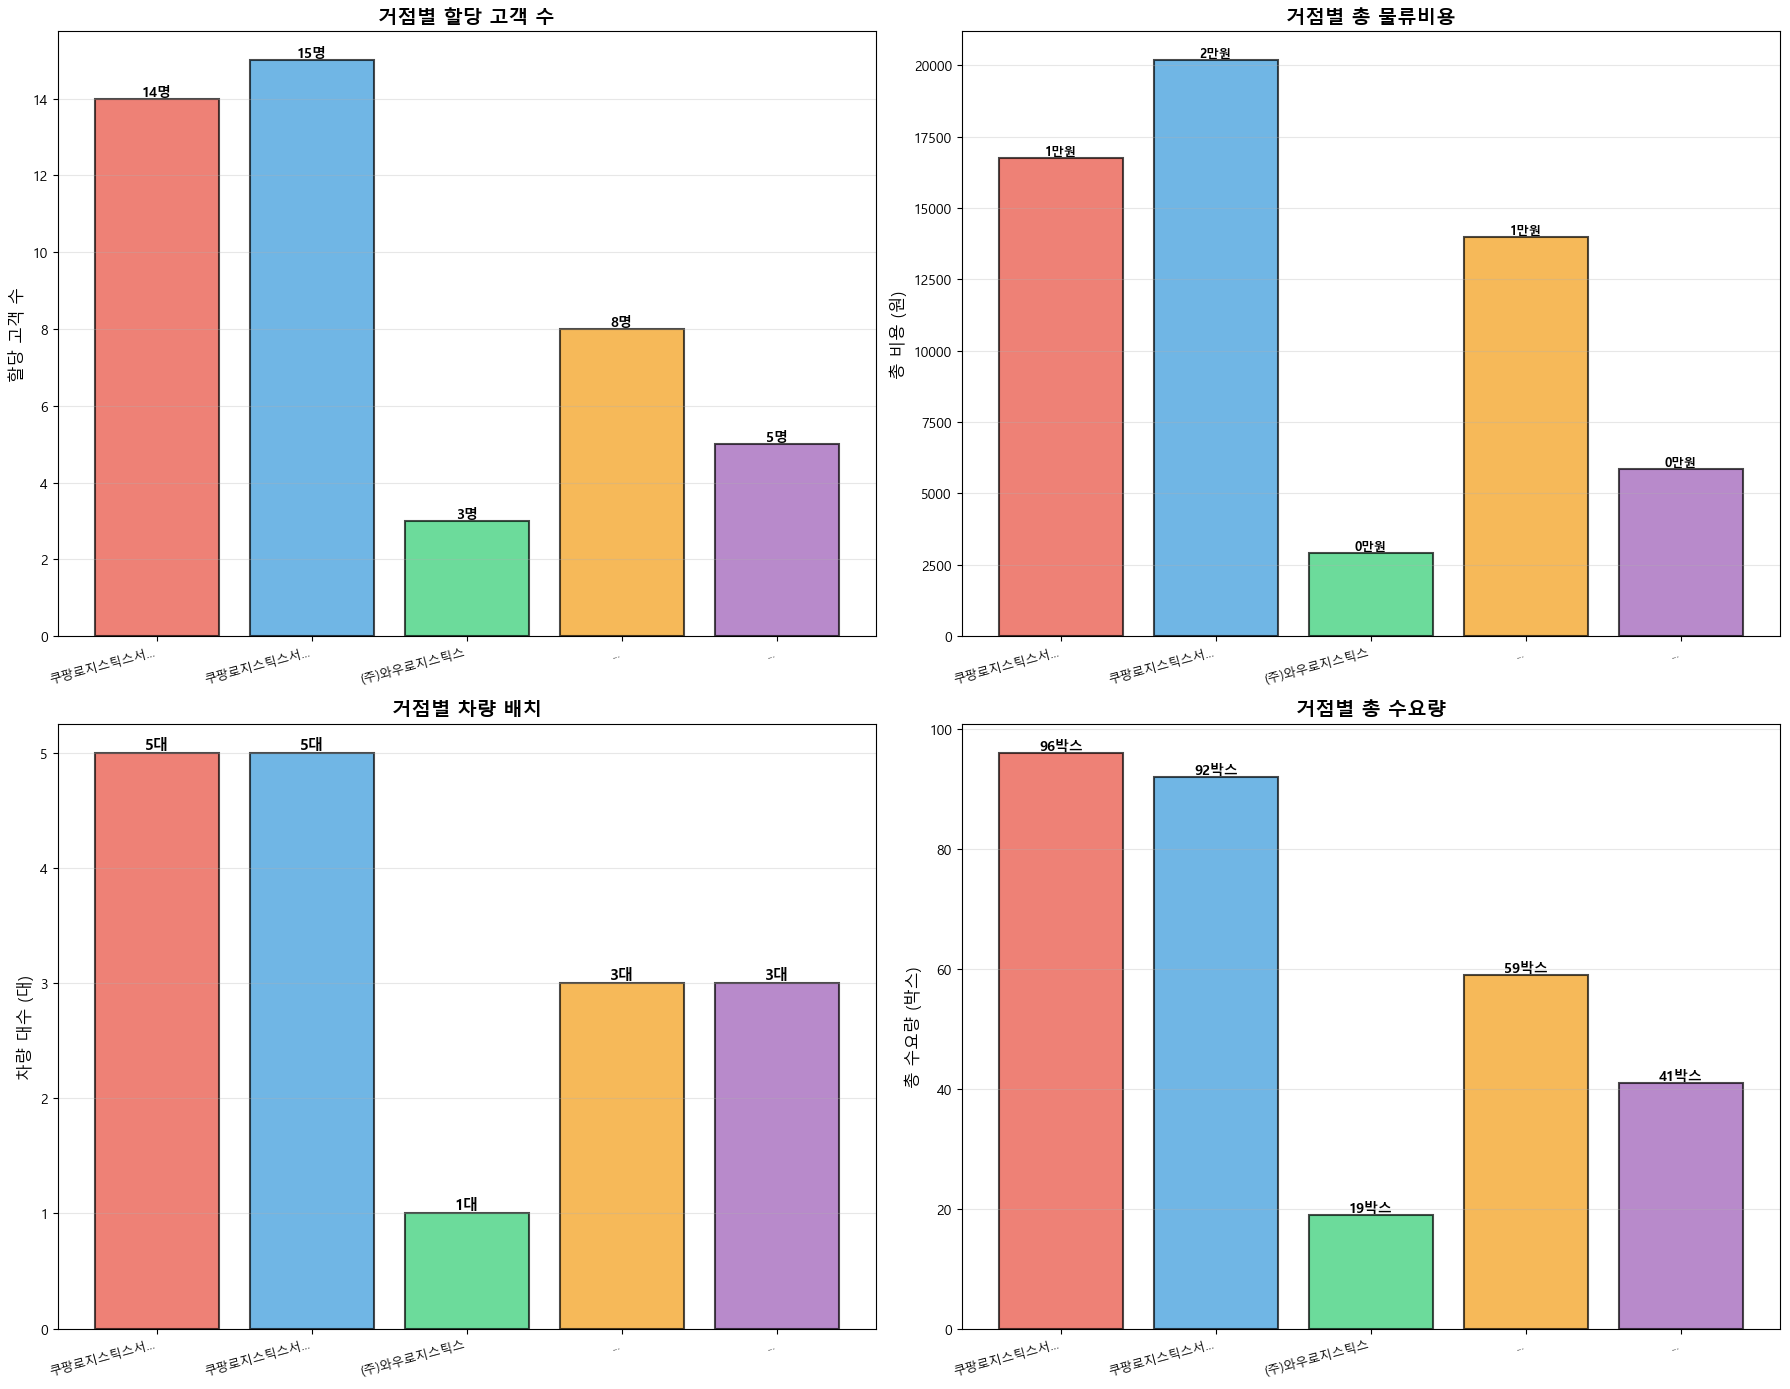

In [44]:
if not df_mdvrp_results.empty:
    # 4개 차트 생성
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # 거점별 색상 설정
    depot_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    # 그래프 1: 거점별 할당 고객 수
    ax1 = axes[0, 0]
    active_depots = df_mdvrp_results[df_mdvrp_results['할당_고객수'] > 0]
    bars = ax1.bar(range(len(active_depots)), active_depots['할당_고객수'], 
                   color=[depot_colors[i] for i in range(len(active_depots))], 
                   alpha=0.7, edgecolor='black', linewidth=1.5)
    ax1.set_xticks(range(len(active_depots)))
    ax1.set_xticklabels([name.split('(')[0][:8] + '...' if len(name) > 10 else name 
                         for name in active_depots['거점명']], rotation=15, ha='right', fontsize=9)
    ax1.set_ylabel('할당 고객 수', fontsize=12)
    ax1.set_title('거점별 할당 고객 수', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}명',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 그래프 2: 거점별 총 비용
    ax2 = axes[0, 1]
    bars = ax2.bar(range(len(active_depots)), active_depots['총_비용(원)'], 
                   color=[depot_colors[i] for i in range(len(active_depots))], 
                   alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.set_xticks(range(len(active_depots)))
    ax2.set_xticklabels([name.split('(')[0][:8] + '...' if len(name) > 10 else name 
                         for name in active_depots['거점명']], rotation=15, ha='right', fontsize=9)
    ax2.set_ylabel('총 비용 (원)', fontsize=12)
    ax2.set_title('거점별 총 물류비용', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height/10000)}만원',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 그래프 3: 거점별 차량 대수
    ax3 = axes[1, 0]
    bars = ax3.bar(range(len(active_depots)), active_depots['차량_대수'], 
                   color=[depot_colors[i] for i in range(len(active_depots))], 
                   alpha=0.7, edgecolor='black', linewidth=1.5)
    ax3.set_xticks(range(len(active_depots)))
    ax3.set_xticklabels([name.split('(')[0][:8] + '...' if len(name) > 10 else name 
                         for name in active_depots['거점명']], rotation=15, ha='right', fontsize=9)
    ax3.set_ylabel('차량 대수 (대)', fontsize=12)
    ax3.set_title('거점별 차량 배치', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}대',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 그래프 4: 거점별 수요량
    ax4 = axes[1, 1]
    bars = ax4.bar(range(len(active_depots)), active_depots['총_수요량'], 
                   color=[depot_colors[i] for i in range(len(active_depots))], 
                   alpha=0.7, edgecolor='black', linewidth=1.5)
    ax4.set_xticks(range(len(active_depots)))
    ax4.set_xticklabels([name.split('(')[0][:8] + '...' if len(name) > 10 else name 
                         for name in active_depots['거점명']], rotation=15, ha='right', fontsize=9)
    ax4.set_ylabel('총 수요량 (박스)', fontsize=12)
    ax4.set_title('거점별 총 수요량', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}박스',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('MDVRP_결과_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 시각화 저장 완료: MDVRP_결과_시각화.png")
    plt.show()
else:
    print("시각화할 결과가 없습니다.")

## 9. MDVRP 지도 시각화 - 거점별 배송 경로


✓ 경로 시각화 저장 완료: MDVRP_배송경로_시각화.png


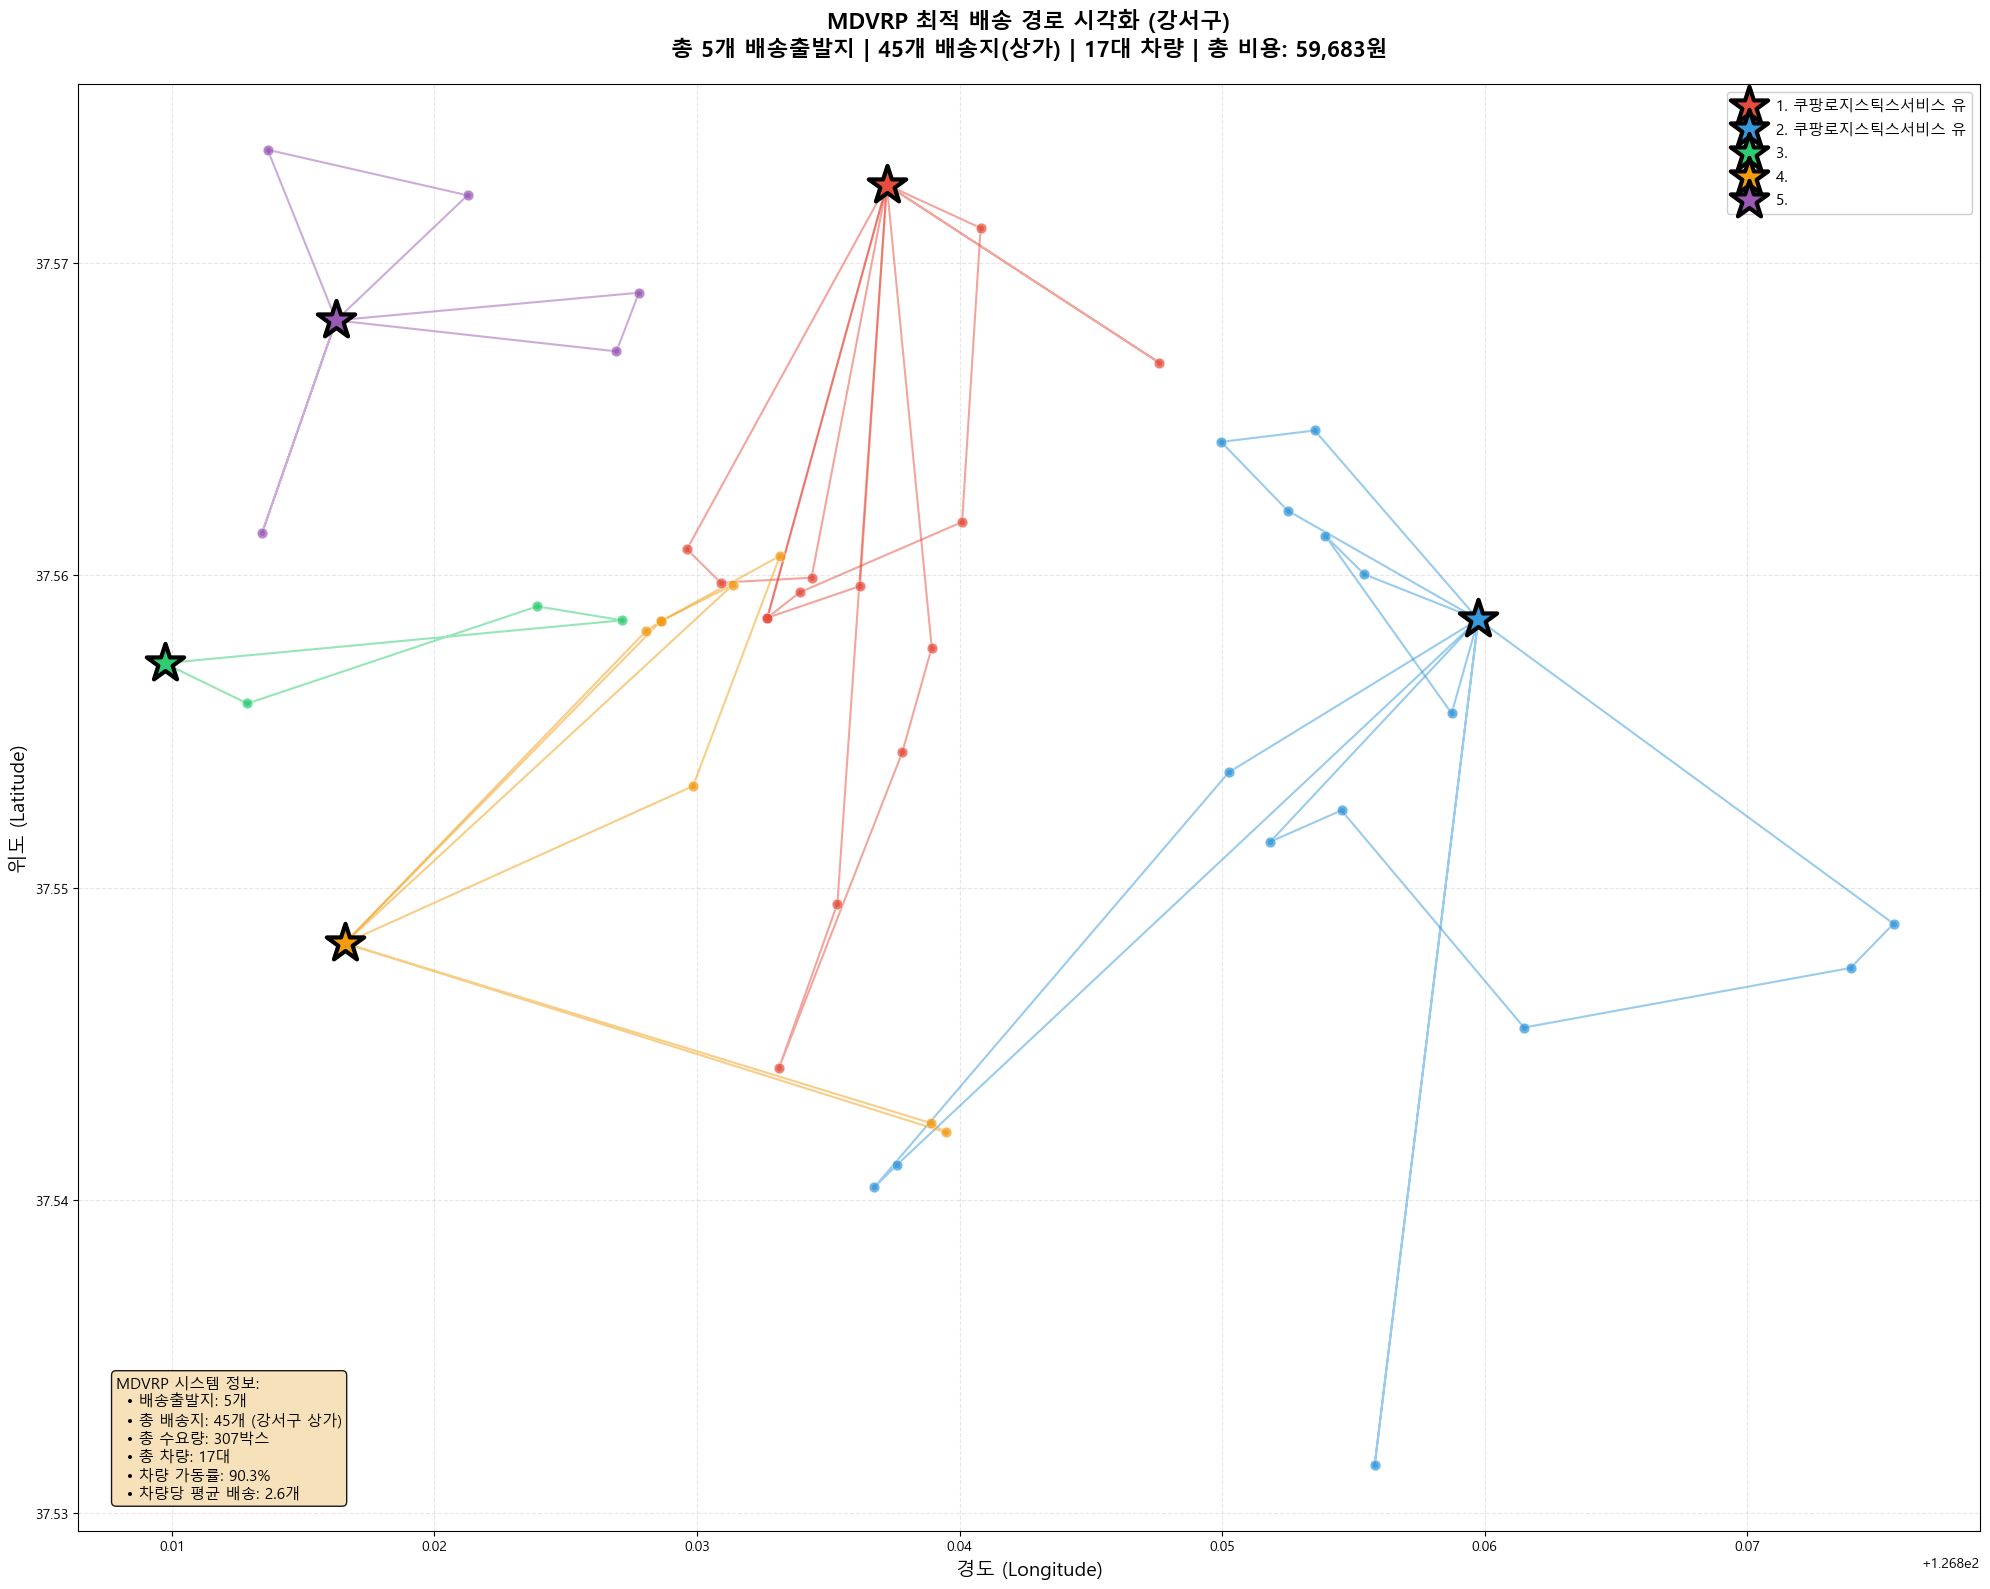


배송출발지별 배송 경로 상세 정보

쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동)):
  - 배송지 수: 14개 (상가)
  - 총 수요량: 96박스
  - 차량 수: 5대
  - 총 비용: 16,744원
  - 차량 가동률: 96.0%

쿠팡로지스틱스서비스 유한회사 (강서1캠프):
  - 배송지 수: 15개 (상가)
  - 총 수요량: 92박스
  - 차량 수: 5대
  - 총 비용: 20,178원
  - 차량 가동률: 92.0%

(주)와우로지스틱스:
  - 배송지 수: 3개 (상가)
  - 총 수요량: 19박스
  - 차량 수: 1대
  - 총 비용: 2,912원
  - 차량 가동률: 95.0%

(주)한진 강서택배센터:
  - 배송지 수: 8개 (상가)
  - 총 수요량: 59박스
  - 차량 수: 3대
  - 총 비용: 13,985원
  - 차량 가동률: 98.3%

(주)케이더블유이코리아:
  - 배송지 수: 5개 (상가)
  - 총 수요량: 41박스
  - 차량 수: 3대
  - 총 비용: 5,864원
  - 차량 가동률: 68.3%


In [45]:
if not df_mdvrp_results.empty:
    # 배송지 좌표
    delivery_lats = df_sample['위도'].values
    delivery_lons = df_sample['경도'].values
    
    # 지도 시각화
    fig, ax = plt.subplots(figsize=(20, 16))
    
    # 거점별 색상 설정
    depot_colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    # 모든 배송지 표시 (회색, 작게)
    ax.scatter(delivery_lons, delivery_lats, c='#95a5a6', s=20, alpha=0.3, 
              zorder=1, edgecolors='none')
    
    # 각 거점별로 처리
    for depot_idx, (depot_node, depot_name) in enumerate(zip(depot_nodes_list, depot_names_list)):
        if depot_node not in mdvrp_results:
            continue
            
        result = mdvrp_results[depot_node]
        if result['num_customers'] == 0:
            continue
        
        color = depot_colors_map[depot_idx]
        depot_info = G.nodes[depot_node]
        depot_lat = depot_info['y']
        depot_lon = depot_info['x']
        
        # 거점 표시
        ax.scatter(depot_lon, depot_lat, c=color, s=800, marker='*', 
                  label=f"{depot_idx+1}. {depot_name.split('(')[0][:12]}", 
                  edgecolors='black', linewidth=3, zorder=10)
        
        # 해당 거점에 할당된 고객 표시
        assigned_indices = result['customer_indices']
        assigned_lats = [df_sample.iloc[idx]['위도'] for idx in assigned_indices]
        assigned_lons = [df_sample.iloc[idx]['경도'] for idx in assigned_indices]
        
        ax.scatter(assigned_lons, assigned_lats, c=color, s=60, alpha=0.7, 
                  edgecolors='white', linewidth=0.5, zorder=5)
        
        # 실제 VRP 경로 그리기: 거점 → 배송지1 → 배송지2 → ... → 거점
        routes = result.get('routes', [])
        for vehicle_idx, route in enumerate(routes):
            # route는 노드 인덱스 리스트: [거점idx, 배송지idx1, 배송지idx2, ..., 거점idx]
            # MDVRP에서 앞 5개(0-4)는 거점, 나머지는 배송지
            route_lons = []
            route_lats = []
            
            for node_idx in route:
                if node_idx < len(depot_nodes_list):  # 거점 노드
                    route_lons.append(depot_lon)
                    route_lats.append(depot_lat)
                else:  # 배송지 노드
                    # 전체 배송지 리스트에서의 실제 인덱스 찾기
                    customer_global_idx = node_idx - len(depot_nodes_list)
                    route_lons.append(df_sample.iloc[customer_global_idx]['경도'])
                    route_lats.append(df_sample.iloc[customer_global_idx]['위도'])
            
            # 경로 선 그리기 (순회 경로)
            if len(route_lons) > 2:  # 거점만 있는 경로 제외
                ax.plot(route_lons, route_lats, color=color, linewidth=1.5, 
                       alpha=0.5, linestyle='-', zorder=3, marker='o', markersize=3)
    
    # 그래프 설정
    ax.set_xlabel('경도 (Longitude)', fontsize=14)
    ax.set_ylabel('위도 (Latitude)', fontsize=14)
    ax.set_title(f'MDVRP 최적 배송 경로 시각화 (강서구)\n'
                f'총 {len(depot_nodes_list)}개 배송출발지 | {len(delivery_nodes)}개 배송지(상가) | '
                f'{total_vehicles}대 차량 | 총 비용: {total_cost:,.0f}원', 
                fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95, ncol=1)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 정보 박스
    info_text = (f'MDVRP 시스템 정보:\n'
                f'  • 배송출발지: {len(depot_nodes_list)}개\n'
                f'  • 총 배송지: {len(delivery_nodes)}개 (강서구 상가)\n'
                f'  • 총 수요량: {sum(demands):.0f}박스\n'
                f'  • 총 차량: {total_vehicles}대\n'
                f'  • 차량 가동률: {sum(demands)/(total_vehicles*vehicles["diesel_1t"]["capacity"])*100 if total_vehicles > 0 else 0:.1f}%\n'
                f'  • 차량당 평균 배송: {len(delivery_nodes)/total_vehicles if total_vehicles > 0 else 0:.1f}개')
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, 
           fontsize=11, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
    
    plt.tight_layout()
    plt.savefig('MDVRP_배송경로_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 경로 시각화 저장 완료: MDVRP_배송경로_시각화.png")
    plt.show()
    
    # 거점별 경로 상세 정보 출력
    print(f"\n{'='*80}")
    print(f"배송출발지별 배송 경로 상세 정보")
    print(f"{'='*80}")
    for depot_node, depot_name in zip(depot_nodes_list, depot_names_list):
        if depot_node not in mdvrp_results:
            continue
        result = mdvrp_results[depot_node]
        if result['num_customers'] == 0:
            print(f"\n{depot_name}: 할당된 고객 없음")
            continue
        
        print(f"\n{depot_name}:")
        print(f"  - 배송지 수: {result['num_customers']}개 (상가)")
        print(f"  - 총 수요량: {result['total_demand']:.0f}박스")
        print(f"  - 차량 수: {result['num_vehicles']}대")
        print(f"  - 총 비용: {result['total_cost']:,.0f}원")
        print(f"  - 차량 가동률: {result['total_demand']/(result['num_vehicles']*vehicles['diesel_1t']['capacity'])*100:.1f}%")
else:
    print("시각화할 결과가 없습니다.")

## 9-2. 휴리스틱 MDVRP 지도 시각화 - 거점별 배송 경로


✓ 휴리스틱 경로 시각화 저장 완료: 휴리스틱_MDVRP_배송경로_시각화.png


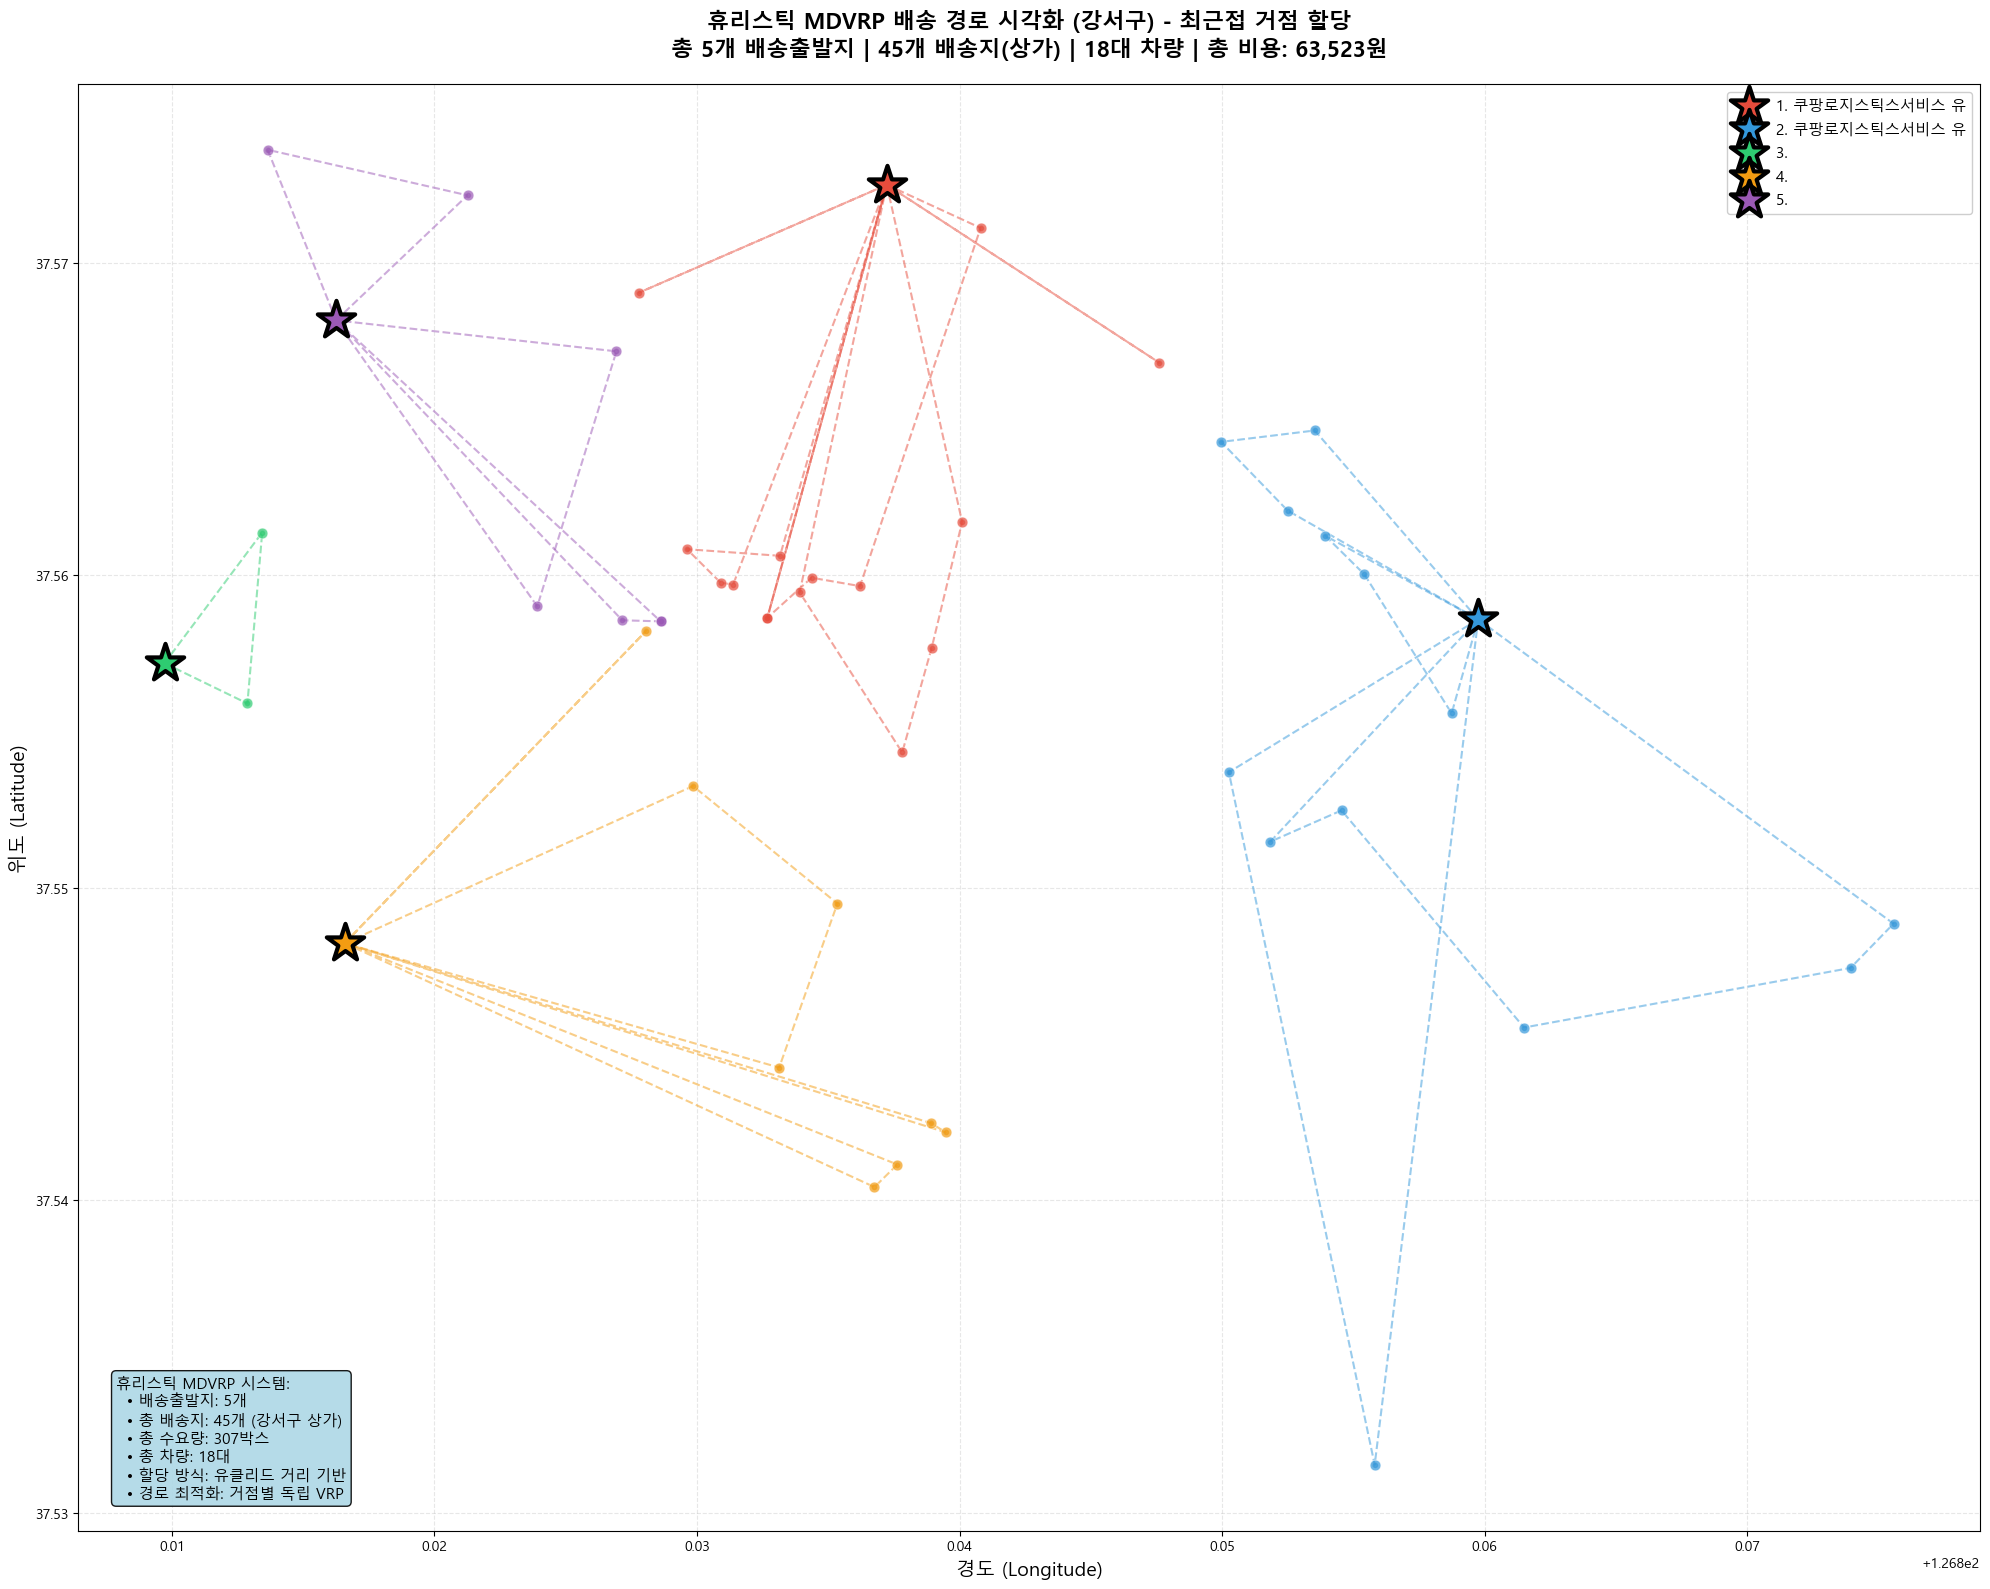


휴리스틱 배송출발지별 배송 경로 상세 정보

쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동)):
  - 배송지 수: 15개 (상가)
  - 총 수요량: 106박스
  - 차량 수: 6대
  - 총 비용: 16,563원
  - 차량 가동률: 88.3%

쿠팡로지스틱스서비스 유한회사 (강서1캠프):
  - 배송지 수: 13개 (상가)
  - 총 수요량: 73박스
  - 차량 수: 4대
  - 총 비용: 15,473원
  - 차량 가동률: 91.2%

(주)와우로지스틱스:
  - 배송지 수: 2개 (상가)
  - 총 수요량: 11박스
  - 차량 수: 1대
  - 총 비용: 2,110원
  - 차량 가동률: 55.0%

(주)한진 강서택배센터:
  - 배송지 수: 8개 (상가)
  - 총 수요량: 72박스
  - 차량 수: 4대
  - 총 비용: 20,712원
  - 차량 가동률: 90.0%

(주)케이더블유이코리아:
  - 배송지 수: 7개 (상가)
  - 총 수요량: 45박스
  - 차량 수: 3대
  - 총 비용: 8,665원
  - 차량 가동률: 75.0%


In [46]:
if 'heuristic_results' in locals() and heuristic_results:
    # 배송지 좌표
    delivery_lats = df_sample['위도'].values
    delivery_lons = df_sample['경도'].values
    
    # 지도 시각화
    fig, ax = plt.subplots(figsize=(20, 16))
    
    # 거점별 색상 설정
    depot_colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    # 모든 배송지 표시 (회색, 작게)
    ax.scatter(delivery_lons, delivery_lats, c='#95a5a6', s=20, alpha=0.3, 
              zorder=1, edgecolors='none')
    
    # 각 거점별로 처리
    for depot_idx, (depot_node, depot_name) in enumerate(zip(depot_nodes_list, depot_names_list)):
        if depot_node not in heuristic_results:
            continue
            
        result = heuristic_results[depot_node]
        if result['num_customers'] == 0:
            continue
        
        color = depot_colors_map[depot_idx]
        depot_info = G.nodes[depot_node]
        depot_lat = depot_info['y']
        depot_lon = depot_info['x']
        
        # 거점 표시
        ax.scatter(depot_lon, depot_lat, c=color, s=800, marker='*', 
                  label=f"{depot_idx+1}. {depot_name.split('(')[0][:12]}", 
                  edgecolors='black', linewidth=3, zorder=10)
        
        # 해당 거점에 할당된 고객 표시
        assigned_indices = result['customer_indices']
        assigned_lats = [df_sample.iloc[idx]['위도'] for idx in assigned_indices]
        assigned_lons = [df_sample.iloc[idx]['경도'] for idx in assigned_indices]
        
        ax.scatter(assigned_lons, assigned_lats, c=color, s=60, alpha=0.7, 
                  edgecolors='white', linewidth=0.5, zorder=5)
        
        # 휴리스틱 VRP 경로 그리기
        routes = result.get('routes', [])
        for vehicle_idx, route in enumerate(routes):
            # route는 거점 기준 상대 인덱스 [0, 배송지1, 배송지2, ..., 0]
            # 0은 거점, 나머지는 assigned_indices의 인덱스
            route_lons = []
            route_lats = []
            
            for node_idx in route:
                if node_idx == 0:  # 거점
                    route_lons.append(depot_lon)
                    route_lats.append(depot_lat)
                else:  # 배송지 (assigned_indices에서의 인덱스)
                    customer_idx = assigned_indices[node_idx - 1]  # route는 1-based
                    route_lons.append(df_sample.iloc[customer_idx]['경도'])
                    route_lats.append(df_sample.iloc[customer_idx]['위도'])
            
            # 경로 선 그리기 (순회 경로)
            if len(route_lons) > 2:  # 거점만 있는 경로 제외
                ax.plot(route_lons, route_lats, color=color, linewidth=1.5, 
                       alpha=0.5, linestyle='--', zorder=3, marker='o', markersize=3)
    
    # 그래프 설정
    ax.set_xlabel('경도 (Longitude)', fontsize=14)
    ax.set_ylabel('위도 (Latitude)', fontsize=14)
    ax.set_title(f'휴리스틱 MDVRP 배송 경로 시각화 (강서구) - 최근접 거점 할당\n'
                f'총 {len(depot_nodes_list)}개 배송출발지 | {len(delivery_nodes)}개 배송지(상가) | '
                f'{heuristic_vehicles}대 차량 | 총 비용: {heuristic_cost:,.0f}원', 
                fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95, ncol=1)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 정보 박스
    info_text = (f'휴리스틱 MDVRP 시스템:\n'
                f'  • 배송출발지: {len(depot_nodes_list)}개\n'
                f'  • 총 배송지: {len(delivery_nodes)}개 (강서구 상가)\n'
                f'  • 총 수요량: {sum(demands):.0f}박스\n'
                f'  • 총 차량: {heuristic_vehicles}대\n'
                f'  • 할당 방식: 유클리드 거리 기반\n'
                f'  • 경로 최적화: 거점별 독립 VRP')
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, 
           fontsize=11, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))
    
    plt.tight_layout()
    plt.savefig('휴리스틱_MDVRP_배송경로_시각화.png', dpi=300, bbox_inches='tight')
    print("\n✓ 휴리스틱 경로 시각화 저장 완료: 휴리스틱_MDVRP_배송경로_시각화.png")
    plt.show()
    
    # 거점별 경로 상세 정보 출력
    print(f"\n{'='*80}")
    print(f"휴리스틱 배송출발지별 배송 경로 상세 정보")
    print(f"{'='*80}")
    for depot_node, depot_name in zip(depot_nodes_list, depot_names_list):
        if depot_node not in heuristic_results:
            continue
        result = heuristic_results[depot_node]
        if result['num_customers'] == 0:
            print(f"\n{depot_name}: 할당된 고객 없음")
            continue
        
        print(f"\n{depot_name}:")
        print(f"  - 배송지 수: {result['num_customers']}개 (상가)")
        print(f"  - 총 수요량: {result['total_demand']:.0f}박스")
        print(f"  - 차량 수: {result['num_vehicles']}대")
        print(f"  - 총 비용: {result['total_cost']:,.0f}원")
        print(f"  - 차량 가동률: {result['total_demand']/(result['num_vehicles']*vehicles['diesel_1t']['capacity'])*100:.1f}%")
else:
    print("휴리스틱 결과가 없습니다. 먼저 휴리스틱 MDVRP를 실행해주세요.")

## 10. MDVRP 결과 요약 및 결론

In [47]:
if not df_mdvrp_results.empty:
    print("\n" + "#"*80)
    print("#" + " "*26 + "MDVRP 최종 결과 요약" + " "*28 + "#")
    print("#"*80)
    
    print(f"\n✓ 물류 시스템 구조:")
    print(f"  - 고정 거점 수: {len(depot_nodes_list)}개")
    print(f"  - 총 배송지: {len(delivery_nodes)}개")
    print(f"  - 총 수요량: {sum(demands):.0f}박스")
    
    print(f"\n✓ 거점별 운영 현황:")
    for depot_node, depot_name in zip(depot_nodes_list, depot_names_list):
        if depot_node in mdvrp_results:
            result = mdvrp_results[depot_node]
            if result['num_customers'] > 0:
                print(f"\n  {depot_name}:")
                print(f"    • 할당 고객: {result['num_customers']}명")
                print(f"    • 수요량: {result['total_demand']:.0f}박스")
                print(f"    • 차량 배치: {result['num_vehicles']}대")
                print(f"    • 운영 비용: {result['total_cost']:,.0f}원")
                print(f"    • 차량 가동률: {result['total_demand']/(result['num_vehicles']*vehicles['diesel_1t']['capacity'])*100 if result['num_vehicles'] > 0 else 0:.1f}%")
    
    print(f"\n✓ 전체 통합 성과:")
    print(f"  - 총 차량 투입: {total_vehicles}대")
    print(f"  - 총 물류비용: {total_cost:,.0f}원")
    print(f"  - 배송지당 평균 비용: {total_cost/len(delivery_nodes):,.0f}원")
    print(f"  - 차량당 평균 비용: {total_cost/total_vehicles if total_vehicles > 0 else 0:,.0f}원")
    print(f"  - 차량당 평균 배송지: {len(delivery_nodes)/total_vehicles if total_vehicles > 0 else 0:.1f}개")
    print(f"  - 전체 차량 가동률: {sum(demands)/(total_vehicles*vehicles['diesel_1t']['capacity'])*100 if total_vehicles > 0 else 0:.1f}%")
    
    # 비용 분해
    vehicle = vehicles['diesel_1t']
    print(f"\n✓ 비용 구성 (km당):")
    print(f"  - 유류비: {vehicle['cost_per_km']}원/km")
    print(f"  - 인건비: {driver_wage_per_km:.0f}원/km")
    co2_per_km = vehicle['co2_per_liter'] / vehicle['fuel_efficiency']
    print(f"  - 탄소세: {co2_per_km * current_carbon_tax_per_kg_co2:.0f}원/km")
    print(f"  - 총 운행비용: {vehicle['cost_per_km'] + driver_wage_per_km + co2_per_km * current_carbon_tax_per_kg_co2:.0f}원/km")
    
    # 단일 거점 대비 MDVRP 장점
    print(f"\n✓ MDVRP 시스템의 장점:")
    print(f"  - 지역별 분산 배송으로 평균 배송 거리 감소")
    print(f"  - 거점별 독립 운영으로 유연한 차량 배치")
    print(f"  - 수요 변화에 따른 탄력적 대응 가능")
    print(f"  - 거점 간 부하 분산으로 안정적 서비스")
    
    print("\n" + "#"*80)
    print("\n✓✓✓ MDVRP 시뮬레이션 완료! ✓✓✓")
    print(f"\n생성된 파일:")
    print("  1. MDVRP_결과_시각화.png (거점별 성과 분석)")
    print("  2. MDVRP_배송경로_시각화.png (지도 경로 시각화)")
    print("\n" + "#"*80)
else:
    print("\n⚠️ MDVRP 결과가 없습니다.")


################################################################################
#                          MDVRP 최종 결과 요약                            #
################################################################################

✓ 물류 시스템 구조:
  - 고정 거점 수: 5개
  - 총 배송지: 45개
  - 총 수요량: 307박스

✓ 거점별 운영 현황:

  쿠팡로지스틱스서비스 유한회사(강서1모바일캠프(마곡동)):
    • 할당 고객: 14명
    • 수요량: 96박스
    • 차량 배치: 5대
    • 운영 비용: 16,744원
    • 차량 가동률: 96.0%

  쿠팡로지스틱스서비스 유한회사 (강서1캠프):
    • 할당 고객: 15명
    • 수요량: 92박스
    • 차량 배치: 5대
    • 운영 비용: 20,178원
    • 차량 가동률: 92.0%

  (주)와우로지스틱스:
    • 할당 고객: 3명
    • 수요량: 19박스
    • 차량 배치: 1대
    • 운영 비용: 2,912원
    • 차량 가동률: 95.0%

  (주)한진 강서택배센터:
    • 할당 고객: 8명
    • 수요량: 59박스
    • 차량 배치: 3대
    • 운영 비용: 13,985원
    • 차량 가동률: 98.3%

  (주)케이더블유이코리아:
    • 할당 고객: 5명
    • 수요량: 41박스
    • 차량 배치: 3대
    • 운영 비용: 5,864원
    • 차량 가동률: 68.3%

✓ 전체 통합 성과:
  - 총 차량 투입: 17대
  - 총 물류비용: 59,683원
  - 배송지당 평균 비용: 1,326원
  - 차량당 평균 비용: 3,511원
  - 차량당 평균 배송지: 2.6개
  - 전체 차량 가동률: 90